# Director Skill Sets Table 7 - Cessation only

In [1]:
import pandas_datareader.data as web #to collect data
import datetime as dt #to specify start and end dates

# import yfinance as yf

import eventstudy as es
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d
%matplotlib inline
import seaborn as sns

import scipy.stats as stats
from scipy.stats.mstats import winsorize
from scipy.spatial.distance import cdist


from sklearn.neighbors import NearestNeighbors

import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.rolling import RollingOLS

from patsy import dmatrices
from tqdm.notebook import tqdm
tqdm.pandas()

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
import_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] CAPM CAR\car_output4"
output_folder_path = "analysis_outputs"
# pca_input_folder_path = rf"..\..\..\[IN USE] Rookie Directors\[1.5] Director Skills PCA\director_skills_pca"
supporting_folder_path = "supporting_datafiles"

In [3]:
dirFirm = pd.read_pickle(rf"{import_folder_path}\Director Level_MF_CAR.pkl")
dirFirm = dirFirm.loc[ dirFirm["date_source"] == "Cessation Date"].reset_index(drop = True)

# pca = pd.read_pickle(rf"{pca_input_folder_path}\Main_Director_COMPLETE_PCA.pkl")

# pca_col = [
#     "Person Code", "AsOnDate", "Symbol",
#     "SkillsetIndex", "SkillsetGeneralistDummy",
#     "PC1_FactorScore", "PC1_FactorScore_Standardised"
# ]

# pca2 = pca[pca_col].copy()
# dirFirm = dirFirm0.merge(pca2, on = ["Person Code", "AsOnDate", "Symbol"], how = "left")

In [4]:
dirFirm

,index,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,CompanyName,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_

In [5]:
# dirFirm data wrangling if any:
dirFirm["Year of Study"] = [x.year for x in dirFirm["Date of Study"]]

dirFirm = dirFirm.drop_duplicates(subset = ["Person Code", "Company", "Date of Study"]).reset_index(drop = True)

dirFirm["ln_dirage"] = np.log(dirFirm["Age"] + 1).astype("float")
dirFirm["ln_directorships"] = np.log(dirFirm["CompCountOtherPastTotalAB"] + 1).astype("float")

In [6]:
dirFirm.describe()

,index,AsOnDate,AsOnYear,Date of Birth,Tenure Valid till,Date of Demise,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,Ownership group code,Prowess company code,govtdummy,findummy,IsMBA,IsPhD,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,Manufacturing_NIC_not used,combined_sustainability,skill_committee_sustainability,combined_entrepreneurial,skill_committee_entrepreneurial,combined_compensation,skill_committee_compensation,combined_conglomerate_experience,skill_committee_conglomerate_experience,combined_hr,skill_committee_hr,combined_technology,skill_committee_technology,combined_finance_accounting,skill_committee_finance_accounting,combined_governance,skill_committee_governance,combined_government_policy,skill_committee_government_policy,combined_international,skill_committee_international,combined_leadership,skill_committee_leadership,combined_legal,skill_committee_legal,combined_marketing,skill_committee_marketing,combined_risk_management,skill_committee_risk_management,combined_scientific,skill_committee_scientific,combined_strategic_planning,skill_committee_strategic_planning,combined_manufacturing_supply_chain,skill_committee_manufacturing_supply_chain,skill_committee_leadership_outside_board,combined_leadership_outside_board,board_corporate governance,board_international business,board_industrials,board_utilities,board_finance,board_telecommunication,board_accounts/audit/taxation,board_public policy,board_risk management,board_research & development,board_legal/compliance,board_services,board_marketing,board_healthcare,board_strategy,board_commodities,board_operations,board_diversity,board_diversified,board_corporate social responsibility,board_human resources,board_fast moving consumer goods,board_economics,board_leadership/management,board_energy,board_financial services,board_information technology,board_personal values,board_consumer discretionary,board_supply chain management,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence,Date of Study,ProwessCode,ACP,pct,RF,RMRF,MF,SMB,HML,OLS120_intercept,OLS120_RMRF,OLS120_r_squared,OLS120_adjusted_r_squared,OLS120_f_p_value,120CAR3,120CAR5,120CAR7,120CAR11,OLS150_intercept,OLS150_RMRF,OLS150_r_squared,OLS150_adjusted_r_squared,OLS150_f_p_value,150CAR3,150CAR5,150CAR7,150CAR11

# PSM

## Verifying and removing those rows with no control data points

In [7]:
# Sample constraints ---> govtdummy==0 & findummy==0 & asonyear>2012
dirFirm.columns.to_list()

['index',
 'Symbol',
 'Company',
 'AsOnDate',
 'AsOnYear',
 'ISIN',
 'Person Code',
 'Director Salutation',
 'Director First Name',
 'Director Middle Name',
 'Director Surname',
 'Date of Birth',
 'Gender',
 'Nationality',
 'Member of Civil Services',
 'Promoter Director (Yes/No)',
 'Position on Board',
 'Independent (Yes/No)',
 'Education1',
 'Education2',
 'Education3',
 'Education4',
 'Education5',
 'Education6',
 'Education7',
 'Education8',
 'Education9',
 'Education10',
 'Skills/Competencies',
 'Occupation',
 'Cessation Reason',
 'Other Directorship 1',
 'Other Directorship 2',
 'Other Directorship 3',
 'Other Directorship 4',
 'Other Directorship 5',
 'Other Directorship 6',
 'Other Directorship 7',
 'Other Directorship 8',
 'Other Directorship 9',
 'Other Directorship 10',
 'Other Directorship 11',
 'Other Directorship 12',
 'Other Directorship 13',
 'Other Directorship 14',
 'Other Directorship 15',
 'Brief Profile',
 'Tenure Valid till',
 'Date of Demise',
 'Indep',
 'Appoint

In [8]:
dirFirm["IsDualityChairmanMD"] = dirFirm["IsDualityChairmanMD"].astype(int)


# dirFirm["NIC_2digit"] = dirFirm["NIC code"].dropna().apply(lambda x: x[0:2])
# dirFirm["NIC_2digit"] = dirFirm["NIC_2digit"]

psmSample = dirFirm.loc[ (dirFirm["Year of Study"] >= 2013)].copy()
# \
# & (dirFirm["govtdummy"] == 0) & (dirFirm["findummy"] == 0) ].copy()
#.dropna(subset = controlVars).dropna(subset = dependentVar).copy()

psmSample["DummySum"] = psmSample["IsRookie"] + psmSample["IsNonRookie"]
psmSample["DummySumIndep"] = psmSample["IsRookieIndep"] + psmSample["IsNonRookieIndep"]

psmSampleAll = psmSample.loc[ psmSample["DummySum"] == 1 ].reset_index(drop = True)
#psmSampleAll = psmSampleAll.loc[ ~psmSampleAll.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

psmSampleIndep = psmSample.loc[ psmSample["DummySumIndep"] == 1 ].reset_index(drop = True)
#psmSampleIndep = psmSampleIndep.loc[ ~psmSampleIndep.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

## CAR windsorization

       winsorised_120CAR3  nonwinsorised_120CAR3
count         8054.000000            8054.000000
mean             0.021145               0.019334
std              1.919818               1.920113
min             -0.130349              -1.390619
25%             -0.036102              -0.036102
50%             -0.005081              -0.005081
75%              0.029597               0.029597
max            172.196754             172.196754


Top values and their count:  nonwinsorised_120CAR3
0.354014      1
0.367410      2
0.396294      2
0.458358      1
0.467639      3
0.474200      1
0.521145      1
0.556494      1
0.579376      1
172.196754    1
Name: count, dtype: int64





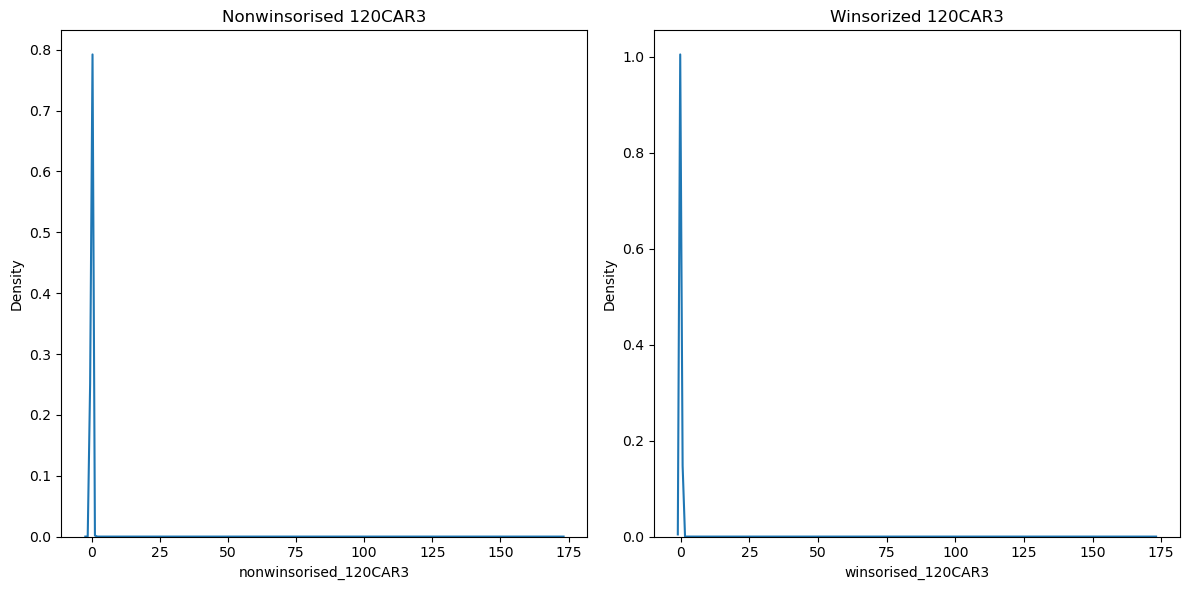

       winsorised_120CAR5  nonwinsorised_120CAR5
count         8054.000000            8054.000000
mean            -0.027984              -0.030261
std              1.920942               1.921420
min             -0.222152              -1.484397
25%             -0.094026              -0.094026
50%             -0.053680              -0.053680
75%             -0.015653              -0.015653
max            172.162555             172.162555


Top values and their count:  nonwinsorised_120CAR5
0.526163      1
0.577019      2
0.592545      1
0.620251      1
0.690441      1
0.825087      1
0.862499      2
0.868369      1
1.325889      2
172.162555    1
Name: count, dtype: int64





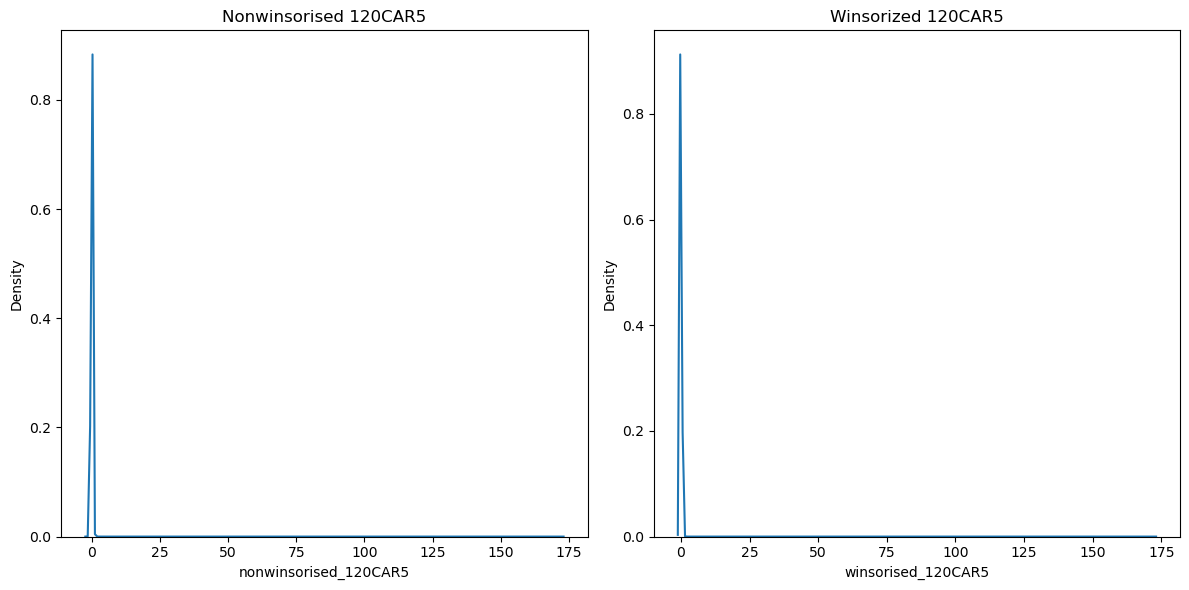

       winsorised_120CAR7  nonwinsorised_120CAR7
count         8049.000000            8049.000000
mean            -0.076649              -0.079223
std              1.922779               1.923343
min             -0.301048              -1.808309
25%             -0.156842              -0.156842
50%             -0.103840              -0.103840
75%             -0.053633              -0.053633
max            172.143174             172.143174


Top values and their count:  nonwinsorised_120CAR7
0.541790      1
0.568037      3
0.580645      2
0.622783      1
0.708274      1
0.780516      2
0.995636      2
1.328174      1
1.640626      1
172.143174    1
Name: count, dtype: int64





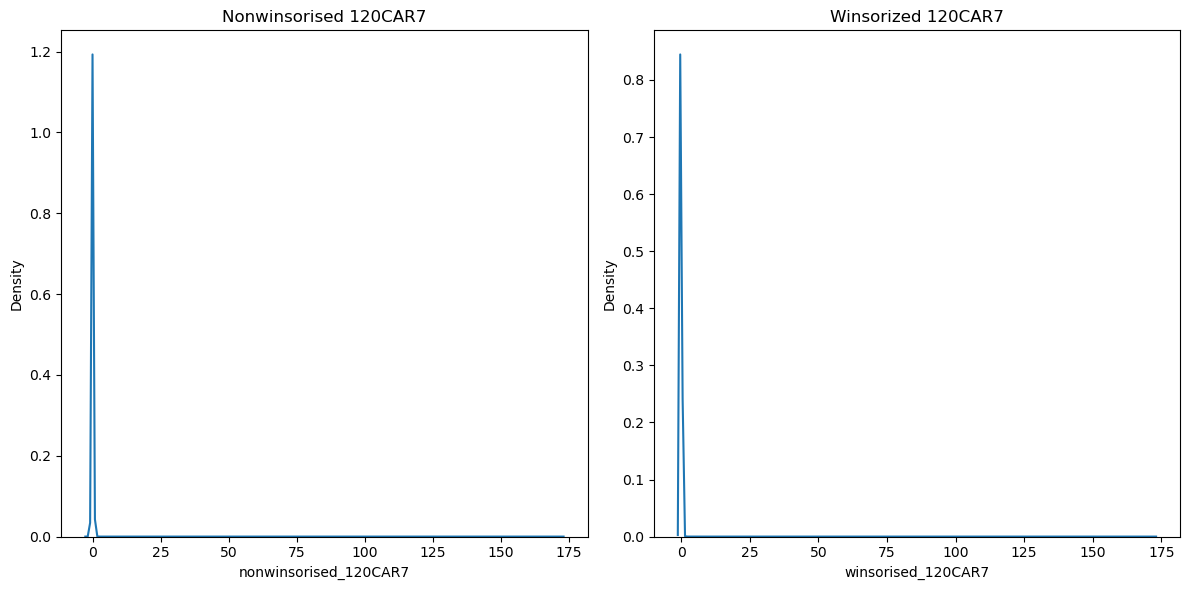

       winsorised_120CAR11  nonwinsorised_120CAR11
count          8048.000000             8048.000000
mean             -0.173023               -0.176733
std               1.925930                1.927018
min              -0.456563               -2.903153
25%              -0.275148               -0.275148
50%              -0.205876               -0.205876
75%              -0.132749               -0.132749
max             171.998594              171.998594


Top values and their count:  nonwinsorised_120CAR11
0.673681      1
0.682899      2
0.719277      1
1.000681      1
1.088694      1
1.157999      1
2.014721      1
2.158702      2
5.807211      1
171.998594    1
Name: count, dtype: int64





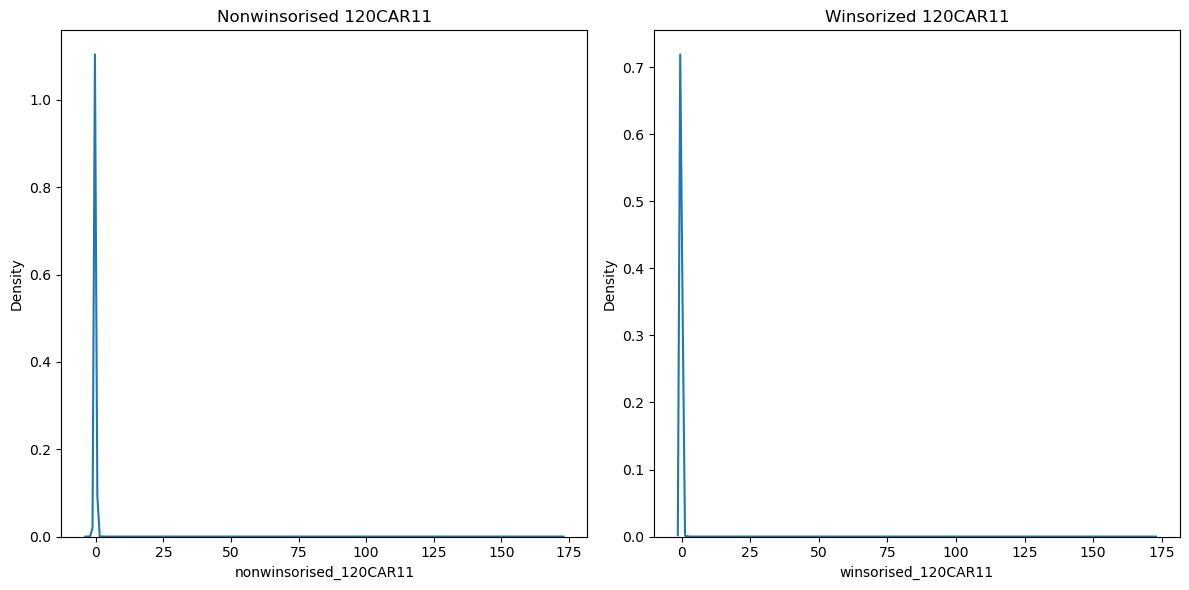

       winsorised_150CAR3  nonwinsorised_150CAR3
count         8034.000000            8034.000000
mean             0.021377               0.019674
std              1.922192               1.922443
min             -0.129590              -1.112824
25%             -0.036364              -0.036364
50%             -0.005025              -0.005025
75%              0.029886               0.029886
max            172.195855             172.195855


Top values and their count:  nonwinsorised_150CAR3
0.368542      2
0.369703      1
0.402356      2
0.457152      1
0.469128      1
0.470429      3
0.519796      1
0.573393      1
0.583729      1
172.195855    1
Name: count, dtype: int64





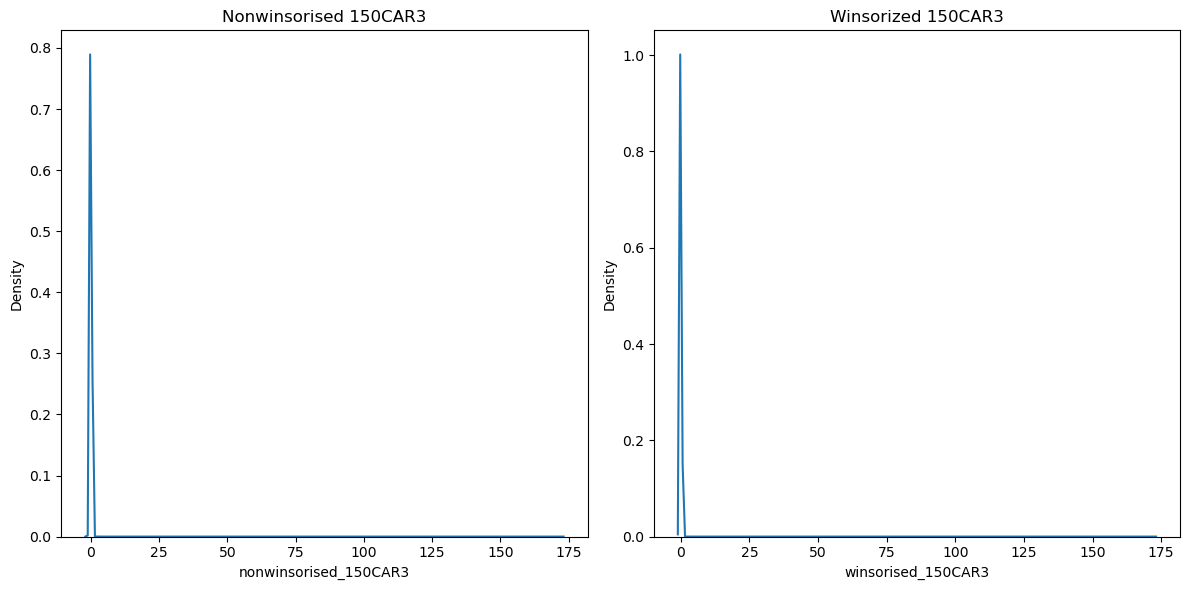

       winsorised_150CAR5  nonwinsorised_150CAR5
count         8034.000000            8034.000000
mean            -0.027774              -0.029985
std              1.923317               1.923735
min             -0.217763              -1.162131
25%             -0.093996              -0.093996
50%             -0.053463              -0.053463
75%             -0.014858              -0.014858
max            172.161791             172.161791


Top values and their count:  nonwinsorised_150CAR5
0.524806      1
0.573516      1
0.581689      2
0.638748      1
0.701324      1
0.856832      1
0.864265      2
0.872016      1
1.340144      2
172.161791    1
Name: count, dtype: int64





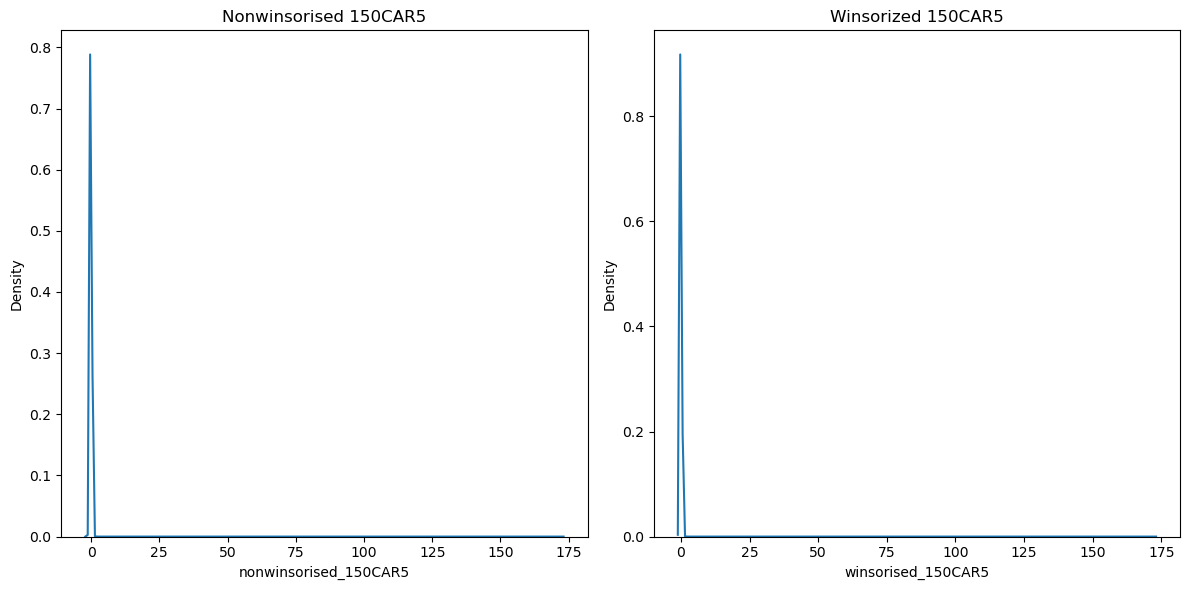

       winsorised_150CAR7  nonwinsorised_150CAR7
count         8029.000000            8029.000000
mean            -0.076766              -0.079226
std              1.925153               1.925641
min             -0.298665              -1.422582
25%             -0.156399              -0.156399
50%             -0.104916              -0.104916
75%             -0.053861              -0.053861
max            172.142993             172.142993


Top values and their count:  nonwinsorised_150CAR7
0.557947      1
0.573521      3
0.574633      2
0.617888      1
0.711893      1
0.799647      2
0.843653      2
1.332583      1
1.652475      1
172.142993    1
Name: count, dtype: int64





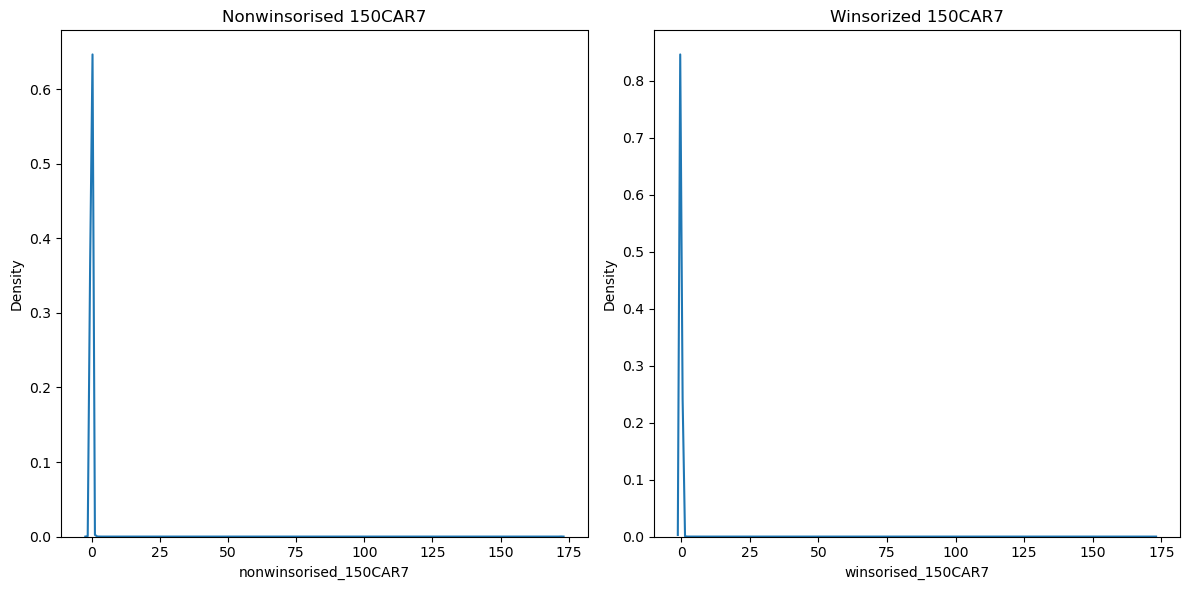

       winsorised_150CAR11  nonwinsorised_150CAR11
count          8028.000000             8028.000000
mean             -0.173625               -0.177086
std               1.928244                1.929173
min              -0.461536               -2.276656
25%              -0.275095               -0.275095
50%              -0.206931               -0.206931
75%              -0.132456               -0.132456
max             171.998645              171.998645


Top values and their count:  nonwinsorised_150CAR11
0.677050      1
0.692702      2
0.714367      1
1.014164      1
1.101002      1
1.182573      1
1.862074      2
2.019356      1
5.805956      1
171.998645    1
Name: count, dtype: int64





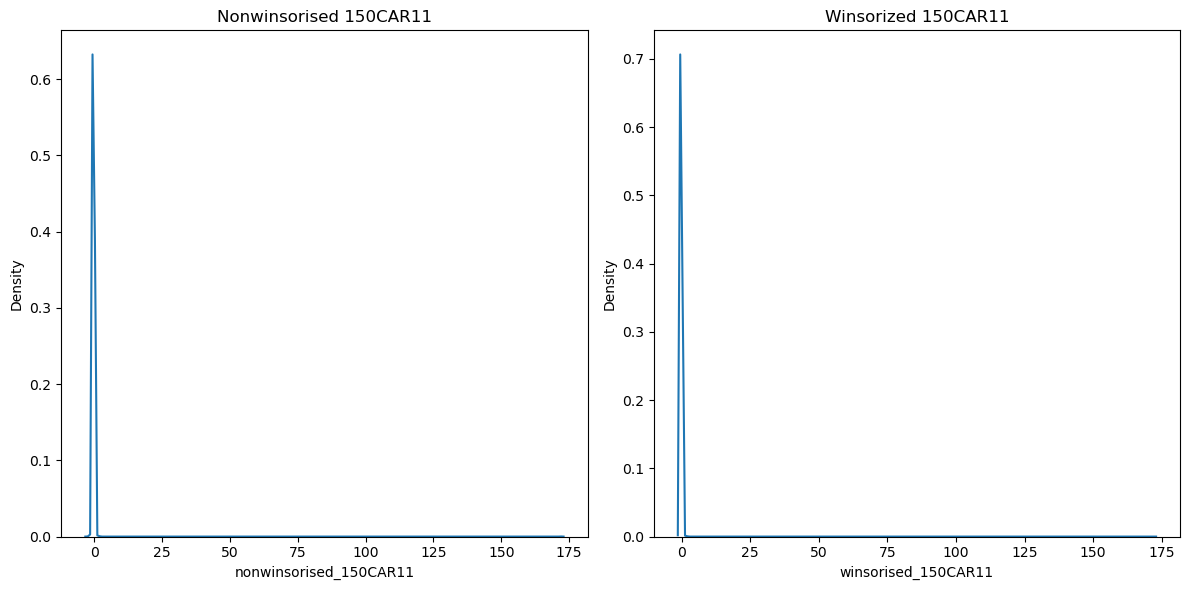

       winsorised_180CAR3  nonwinsorised_180CAR3
count         8004.000000            8004.000000
mean             0.021303               0.019563
std              1.925812               1.926062
min             -0.131509              -0.923095
25%             -0.036828              -0.036828
50%             -0.005136              -0.005136
75%              0.030386               0.030386
max            172.197104             172.197104


Top values and their count:  nonwinsorised_180CAR3
0.361125      2
0.363167      1
0.389323      2
0.459640      1
0.469022      1
0.476559      3
0.524774      1
0.584829      1
0.598306      1
172.197104    1
Name: count, dtype: int64





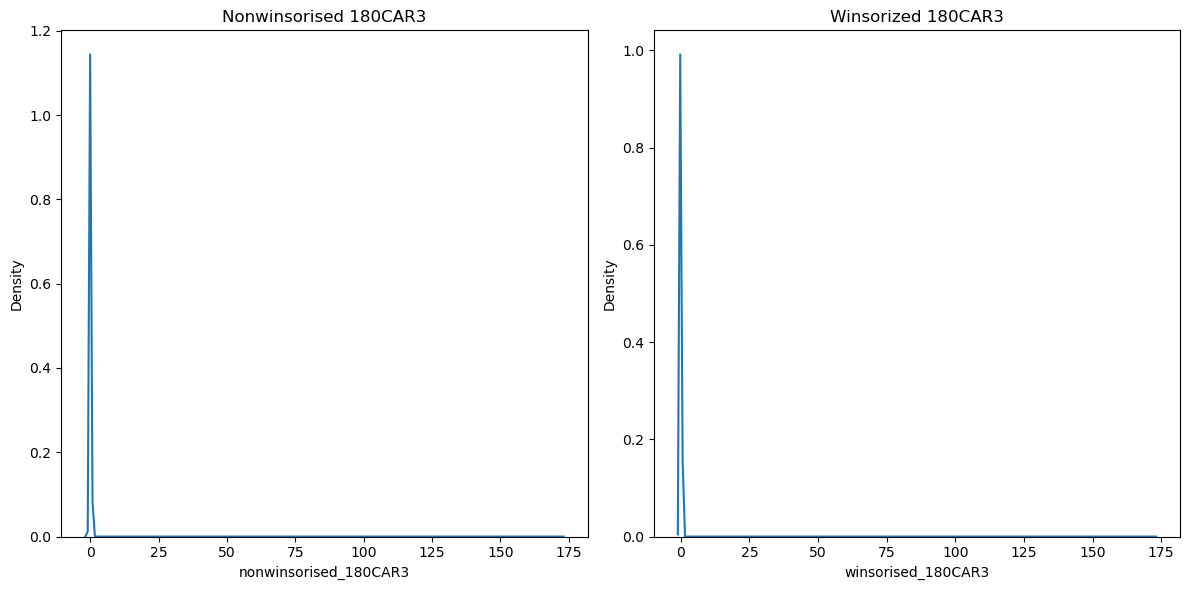

       winsorised_180CAR5  nonwinsorised_180CAR5
count         8004.000000            8004.000000
mean            -0.027919              -0.030145
std              1.926920               1.927324
min             -0.219601              -1.024428
25%             -0.094479              -0.094479
50%             -0.054155              -0.054155
75%             -0.015079              -0.015079
max            172.162883             172.162883


Top values and their count:  nonwinsorised_180CAR5
0.529765      1
0.553240      2
0.584543      1
0.654920      1
0.752163      1
0.768421      2
0.823484      1
0.872663      1
1.321390      2
172.162883    1
Name: count, dtype: int64





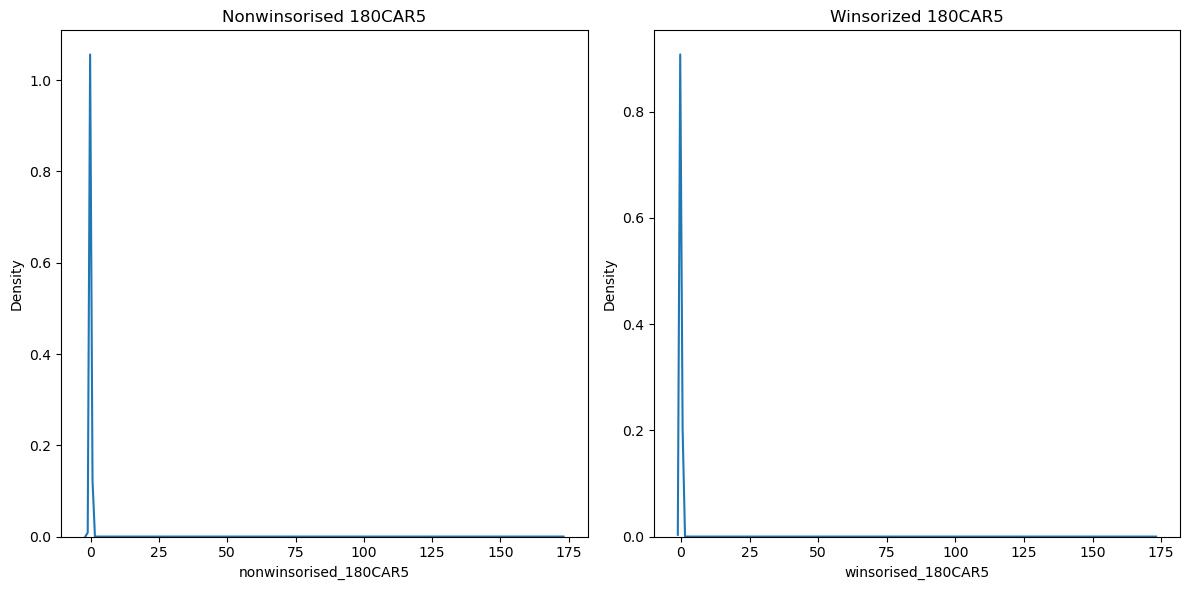

       winsorised_180CAR7  nonwinsorised_180CAR7
count         7999.000000            7999.000000
mean            -0.076843              -0.079285
std              1.928815               1.929277
min             -0.300232              -1.183477
25%             -0.156163              -0.156163
50%             -0.105842              -0.105842
75%             -0.053686              -0.053686
max            172.143403             172.143403


Top values and their count:  nonwinsorised_180CAR7
0.573549      1
0.578471      2
0.585563      3
0.617150      1
0.712493      1
0.777487      2
1.157361      2
1.333720      1
1.700582      1
172.143403    1
Name: count, dtype: int64





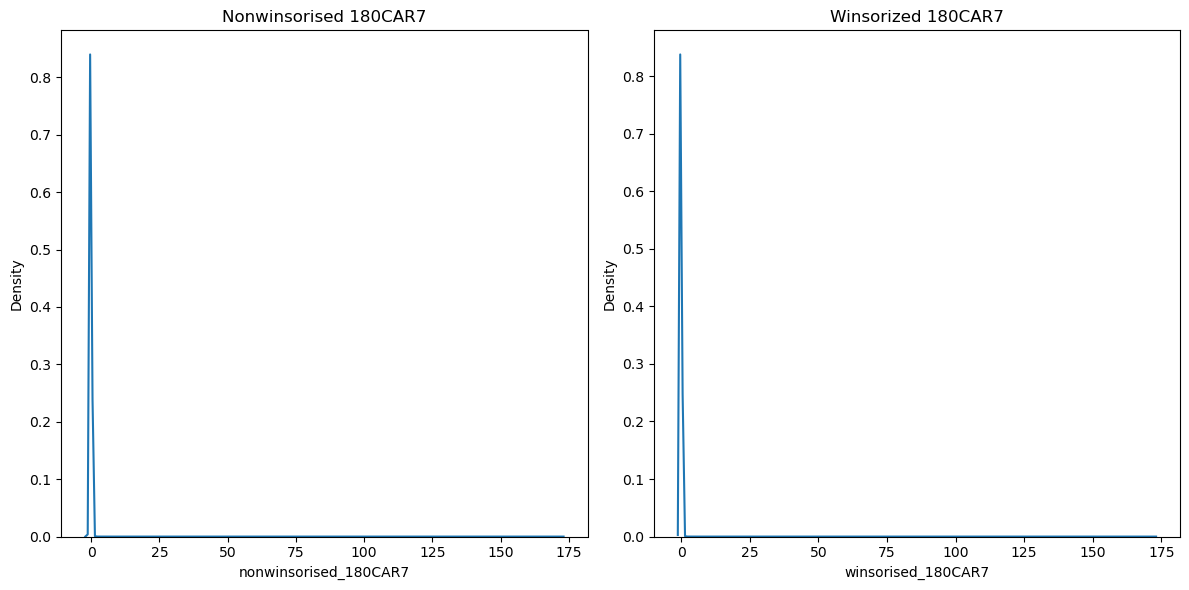

       winsorised_180CAR11  nonwinsorised_180CAR11
count          7998.000000             7998.000000
mean             -0.173655               -0.176895
std               1.932087                1.932917
min              -0.465197               -1.854222
25%              -0.275553               -0.275553
50%              -0.206756               -0.206756
75%              -0.132634               -0.132634
max             171.998783              171.998783


Top values and their count:  nonwinsorised_180CAR11
0.677057      2
0.677832      1
0.713352      1
1.023327      1
1.147810      1
1.154306      1
2.020638      1
2.561080      2
5.806742      1
171.998783    1
Name: count, dtype: int64





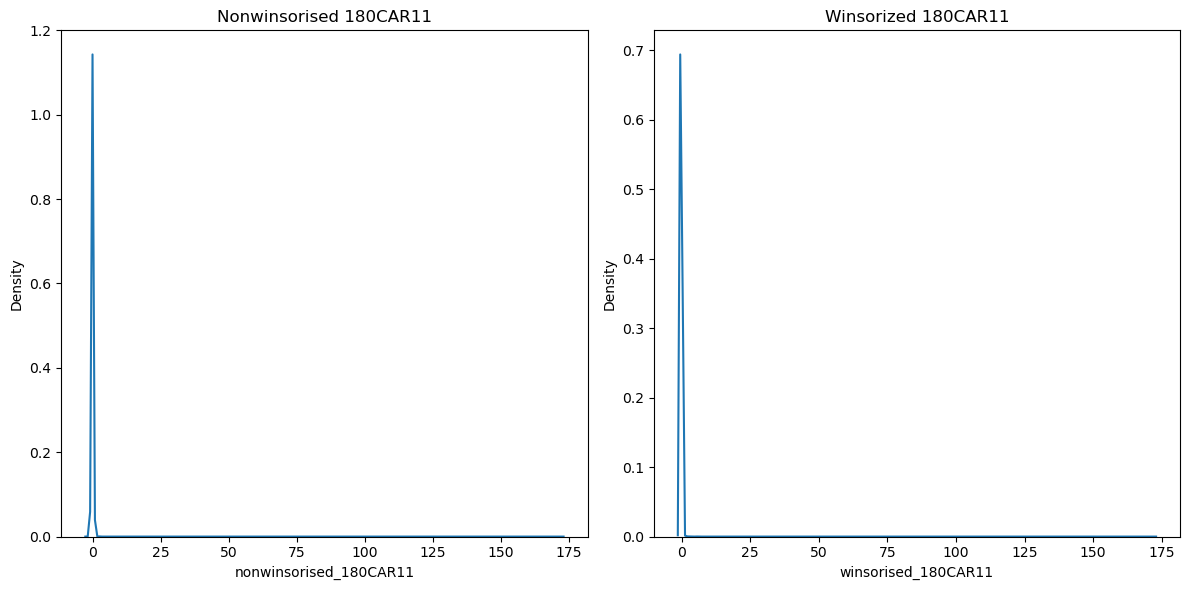

       winsorised_210CAR3  nonwinsorised_210CAR3
count         7975.000000            7975.000000
mean             0.021599               0.019707
std              1.929289               1.929583
min             -0.130252              -1.293352
25%             -0.036790              -0.036790
50%             -0.005036              -0.005036
75%              0.030399               0.030399
max            172.195614             172.195614


Top values and their count:  nonwinsorised_210CAR3
0.359733      1
0.368427      2
0.395703      2
0.456135      1
0.471367      1
0.479239      3
0.521263      1
0.585313      1
0.615202      1
172.195614    1
Name: count, dtype: int64





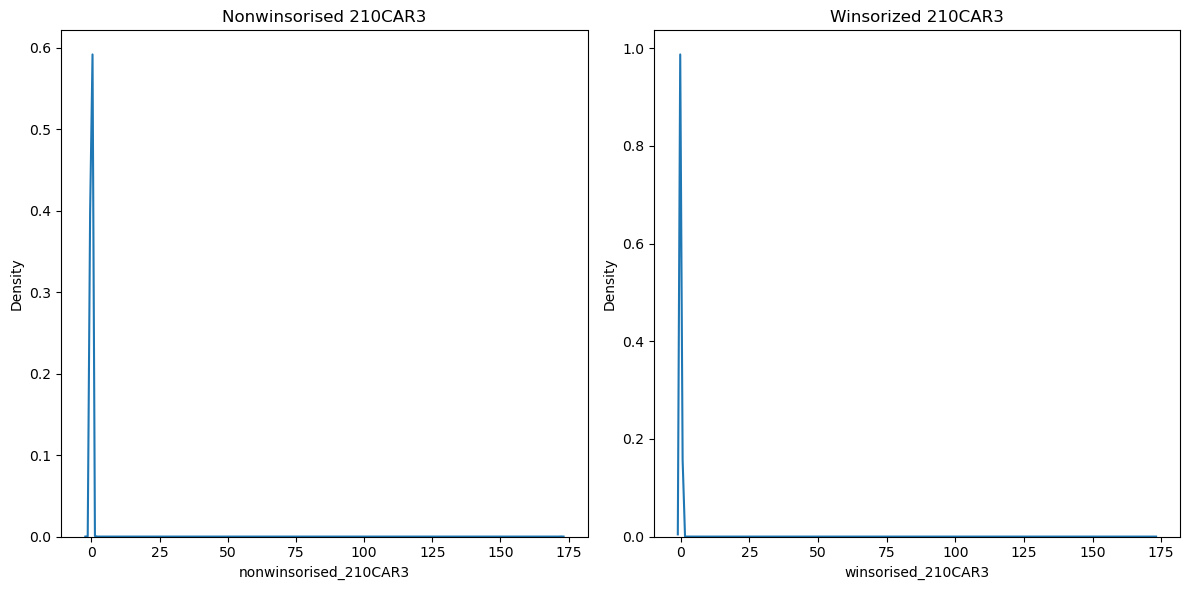

       winsorised_210CAR5  nonwinsorised_210CAR5
count         7975.000000            7975.000000
mean            -0.027665              -0.029957
std              1.930417               1.930848
min             -0.221465              -1.330682
25%             -0.094148              -0.094148
50%             -0.054178              -0.054178
75%             -0.015114              -0.015114
max            172.161688             172.161688


Top values and their count:  nonwinsorised_210CAR5
0.526290      1
0.572693      1
0.575218      2
0.671156      1
0.759265      2
0.766865      1
0.838681      1
0.872740      1
1.332876      2
172.161688    1
Name: count, dtype: int64





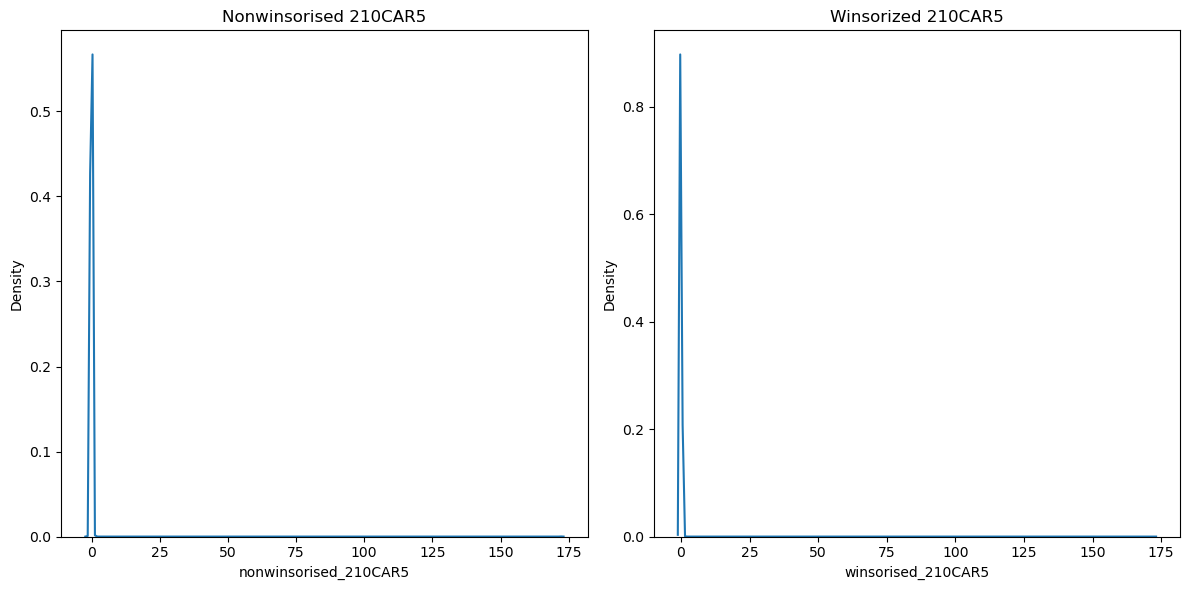

       winsorised_210CAR7  nonwinsorised_210CAR7
count         7970.000000            7970.000000
mean            -0.076711              -0.079229
std              1.932339               1.932844
min             -0.302331              -1.581657
25%             -0.156503              -0.156503
50%             -0.105536              -0.105536
75%             -0.053585              -0.053585
max            172.143482             172.143482


Top values and their count:  nonwinsorised_210CAR7
0.581096      2
0.587775      3
0.590296      1
0.617164      1
0.712379      1
0.792013      2
1.221736      2
1.334236      1
1.714716      1
172.143482    1
Name: count, dtype: int64





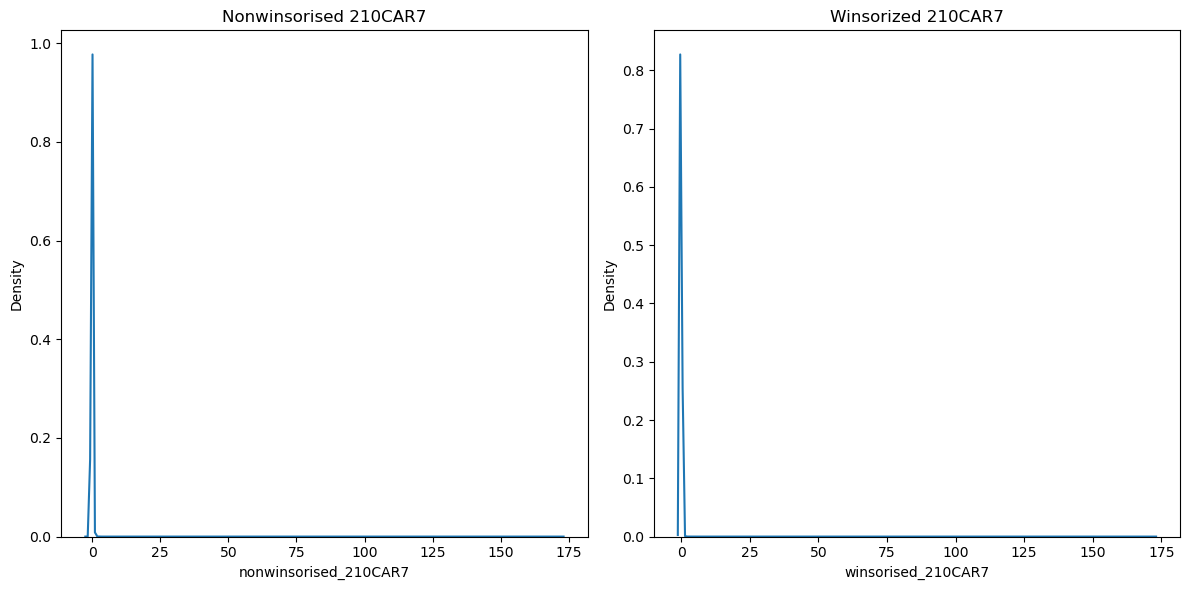

       winsorised_210CAR11  nonwinsorised_210CAR11
count          7969.000000             7969.000000
mean             -0.173511               -0.176766
std               1.935664                1.936478
min              -0.466319               -1.603810
25%              -0.275335               -0.275335
50%              -0.206556               -0.206556
75%              -0.132692               -0.132692
max             171.999371              171.999371


Top values and their count:  nonwinsorised_210CAR11
0.680811      1
0.685767      2
0.713342      1
1.042222      1
1.161674      1
1.167972      1
2.021285      1
2.694633      2
5.807275      1
171.999371    1
Name: count, dtype: int64





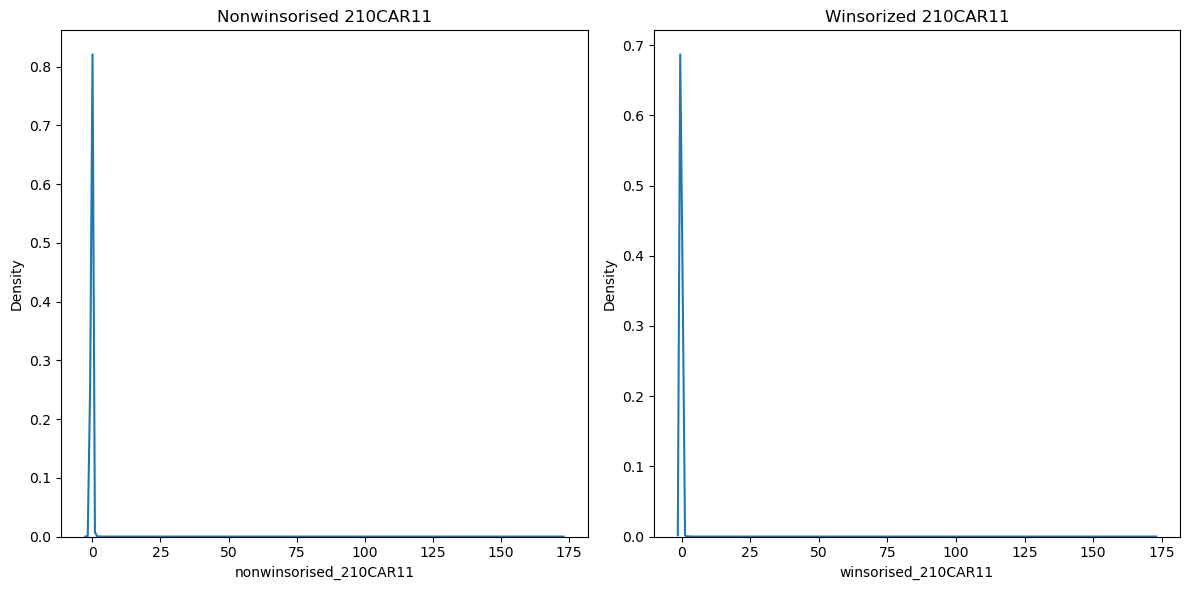

In [9]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

from scipy.stats.mstats import winsorize

def winsorize_output(sample, variable, limits = [0, 0]):
    sample[f"nonwinsorised_{variable}"] = sample[variable]
    sample[f"winsorised_{variable}"] = winsorize(np.array(sample[f"nonwinsorised_{variable}"]), limits = limits, inclusive = [False, False])
    sample[[f"nonwinsorised_{variable}", f"winsorised_{variable}"]].describe()
    print(sample[[f"winsorised_{variable}", f"nonwinsorised_{variable}"]].describe())
    print("\n\nTop values and their count: ", (sample[f"nonwinsorised_{variable}"].value_counts().sort_index().tail(n=10)))
    print("\n\n")
    
    # Graphs
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
    sns.kdeplot(data = sample[f"nonwinsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[0])
    axes[0].set_title(f'Nonwinsorised {variable}')
    sns.kdeplot(data = sample[f"winsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[1])
    axes[1].set_title(f'Winsorized {variable}')
    plt.tight_layout()
    plt.show()

    sample[variable] = sample[f"winsorised_{variable}"]
    return sample[variable]

for car in carCol:
    psmSampleIndep[car] = winsorize_output(psmSampleIndep, car, [0.01, 0.01])

In [10]:
# dirFirm2 = dirFirm.copy()
# psmSampleIndep2 = psmSampleIndep.copy()

# listCol = [
#     "FirstYearPCodeList", "TwoYearPCodeList", "ThreeYearPCodeList", "PCodeList",
#     "FirstYearIndepPCodeList", "TwoYearIndepPCodeList", "ThreeYearIndepPCodeList", "IndepPCodeList",
#     "OtherFirstYearIndepPCode", "OtherTwoYearIndepPCode", "OtherThreeYearIndepPCode", "TotalIndepPCode",
#     "OtherFirstYearPCode", "OtherTwoYearPCode", "OtherThreeYearPCode", "TotalPCode",
#     "OtherFirstYearPCodeIndepExcl","OtherTwoYearPCodeIndepExcl", "OtherThreeYearPCodeIndepExcl", "TotalPCodeIndepExcl",
#     "OtherFirstYearPCodeExcl", "OtherTwoYearPCodeExcl", "OtherThreeYearPCodeExcl", "TotalPCodeExcl"
# ]

# dirFirm2 = dirFirm2.drop(listCol, axis = 1)
# psmSampleIndep2 = psmSampleIndep2.drop(listCol, axis = 1)


# dirFirm2.to_csv("Main_Firm_PSM Ready_no filter v040425.csv")
# psmSampleIndep2.to_csv("Main_Firm_PSM Ready_filter-Indep_gov_fin v040425.csv")


# # # psmSampleAll --> 2101 rows 
# # psmSampleIndep --> 1561 rows 

## PSM --> RookieAppoints as Treatment, NonRookieAppoints as Control

In [11]:
def LogitReg(sample, endog_var, exog_var):
    
    # Logit Regression
    endog = sample[endog_var]
    exog = sample[exog_var]
    
    scaler = StandardScaler()
    exog_standardised = pd.DataFrame(scaler.fit_transform(exog), columns=exog.columns)

    exog_standardised = sm.add_constant(exog_standardised)
    
    log_reg = sm.Logit(endog, exog_standardised).fit()

    propensityScores = log_reg.predict(exog_standardised)
    
    return propensityScores

In [12]:
def MeanDiffTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    if depVar != None:
        dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
        colsAdd = []
        for i in range(-1, 4):
            if i != 0:
                colsAdd.append(f"AsOnYear_T+{i}")
                colsAdd.append(f"{depVar}T+{i}")
                if i>0 :
                    colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
        newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "float")
        sample = pd.concat([sample, newFrame], axis = 1)
        sample = sample.copy()
        
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
                                                              right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
        for i in range(1, 4):
            if i != 0:
                sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
        sample = sample.copy()
    
    group1 = sample.loc[ sample[endog_var] == 1].copy()
    group2 = sample.loc[ sample[endog_var] == 0].copy()
    
    t_stat, p_value = stats.ttest_ind(group1[car], group2[car], equal_var=False)  # Welch’s t-test (default)

    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Treated Mean:", group1[car].mean(), " Control Mean:", group2[car].mean(), " Diff:", group1[car].mean() - group2[car].mean())
    print("Treated Median:", group1[car].median(), " Control Median:", group2[car].median(), " Diff:", group1[car].median() - group2[car].median())
    print("Treated N:", len(group1[car]), "; Control N:", len(group2[car]))
    print("[treated unique = ", len(group1.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]",\
          "[control unique = ", len(group2.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]"
         )
    print("\n")

    # -----------------------------------------------------------------------------------------------------------------
    
    if exog_var != None:
        print("━"*120)
        print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
        print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
        print("-"*120)

        for var in exog_var:
            treatMean = group1[var].mean()
            controlMean = group2[var].mean()
            p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
            print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
        print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    if depVar != None:
        print(depVar, " across years:\n")
        for i in range(1,4):
            sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
        group1 = sample.loc[ sample[endog_var] == 1].copy()
        group2 = sample.loc[ sample[endog_var] == 0].copy()

        print("━"*150, "\n")
        print(f'{depVar:<40}{" ":<20}{"Treatment":<20}{"Control":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
        print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
        print("─"*150, "\n")
    
        for i in range(1,4):
            t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
            treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
            controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
            diffMean = treatedMean - controlMean
    
            treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
            controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
            diffMedian = treatedMedian - controlMedian
    
            print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
            label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            label2 = "Control N: " + str(len(group2[depVar+f'(T+{i}) - (T-1)']))
            
            print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
            print("-"*150, "\n")
            
        print("━"*150, "\n")

    return

In [13]:
def OneSampleTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    # if depVar != None:
    #     dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
    #     colsAdd = []
    #     for i in range(-1, 4):
    #         if i != 0:
    #             colsAdd.append(f"AsOnYear_T+{i}")
    #             colsAdd.append(f"{depVar}T+{i}")
    #             if i>0 :
    #                 colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
    #     newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "int")
    #     sample = pd.concat([sample, newFrame], axis = 1)
    #     sample = sample.copy()
        
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
    #                                                           right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
    #     for i in range(1, 4):
    #         if i != 0:
    #             sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
    #     sample = sample.copy()
    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    group1 = sample.copy()
    
    t_stat, p_value = stats.ttest_1samp(group1[car], 0)  # Welch’s t-test (default)
    
    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Mean:", group1[car].mean())
    print("Median:", group1[car].median())
    print("N:", len(group1[car]))

    print("\n")

    # -----------------------------------------------------------------------------------------------------------------




    # if exog_var != None:
    #     print("━"*120)
    #     print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
    #     print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
    #     print("-"*120)

    #     for var in exog_var:
    #         treatMean = group1[var].mean()
    #         controlMean = group2[var].mean()
    #         p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
    #         print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
    #     print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    # if depVar != None:
    #     print(depVar, " across years:\n")
    #     for i in range(1,4):
    #         sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
    #     group1 = sample.loc[ sample[endog_var] == 1].copy()
    #     group2 = sample.loc[ sample[endog_var] == 0].copy()

    #     print("━"*150, "\n")
    #     print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
    #     print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
    #     print("─"*150, "\n")
    
    #     for i in range(1,4):
    #         t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
    #         treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
    #         controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
    #         diffMean = treatedMean - controlMean
    
    #         treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
    #         controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
    #         diffMedian = treatedMedian - controlMedian
    
    #         print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
    #         label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
    #         label2 = "Control N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            
    #         print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
    #         print("-"*150, "\n")
            
    #print("━"*150, "\n")

    return

In [14]:
def PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    treated = sample.loc[ sample[endog_var] == 1].copy()
    control = sample.loc[ sample[endog_var] == 0].copy()

    # Nearest Neighbours
    nn = NearestNeighbors(n_neighbors = 1, metric = "euclidean")
    nn.fit(control[["propensityScore"]])

    distances, indices = nn.kneighbors(treated[["propensityScore"]])
    
    matchedControl = control.iloc[indices.flatten()].copy()
    
    matched = pd.concat([treated, matchedControl])
    matched.reset_index(drop=True, inplace=True)

    MeanDiffTtest(matched, endog_var, exog_var, car, depVar, dirFirm)

    return

In [15]:
# Func PSM non replacement
def PsmNonReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    # Separate treated and control groups
    treated = sample[sample[endog_var] == 1].copy()
    control = sample[sample[endog_var] == 0].copy()
    
    # Compute pairwise distances (absolute difference in propensity scores)
    dist_matrix = cdist(treated[['propensityScore']], control[['propensityScore']], metric='euclidean')
    
    # Match without replacement
    treated_indices = []
    matched_indices = []
    used_control_indices = set()
    
    for i in range(len(treated)):
        if len(used_control_indices) >= len(control):  # Stop if no controls left
            print("Warning: Not enough control units to match all treated units.")
            break
        
        # Get nearest control unit index that hasn't been used
        match_idx = np.argmin(dist_matrix[i])
        
        while match_idx in used_control_indices:  # Ensure it's not already matched
            dist_matrix[i, match_idx] = np.inf  # Temporarily set distance to infinity

            if np.all(dist_matrix[i] == np.inf):  # If all controls are exhausted
                print(f"No available control for treated unit {i}, skipping.")
                match_idx = None
                break
            
            match_idx = np.argmin(dist_matrix[i])
        
        used_control_indices.add(match_idx)
        matched_indices.append(match_idx)
        treated_indices.append(i)
    
    # Retrieve matched units
    matched_control = control.iloc[matched_indices].copy()
    matched_treated = treated.iloc[treated_indices].copy()
    
    # Combine matched treated and control units
    matched_data = pd.concat([matched_treated.reset_index(drop=True), matched_control.reset_index(drop=True)])
    
    # Reset index
    matched_data.reset_index(drop=True, inplace=True)


    # Mean difference and T Test
    MeanDiffTtest(matched_data, endog_var, exog_var, car, depVar, dirFirm)

    return
    


In [16]:
psmSampleIndep

,index,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,CompanyName,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_

# CAR Plots

### Total Sample

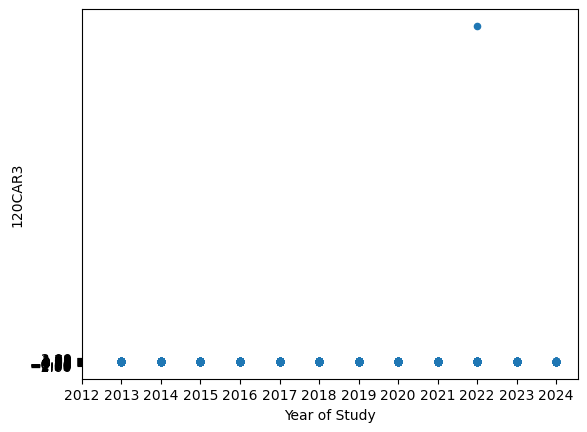

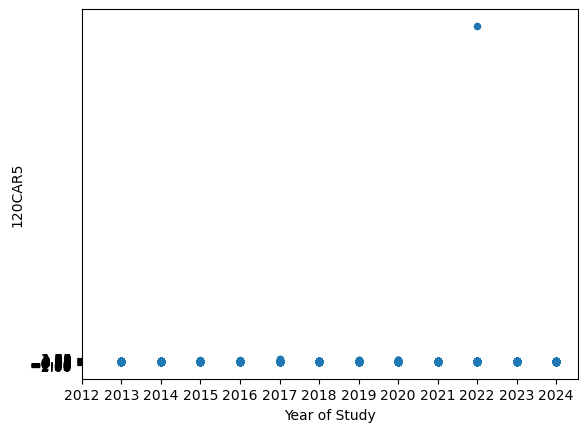

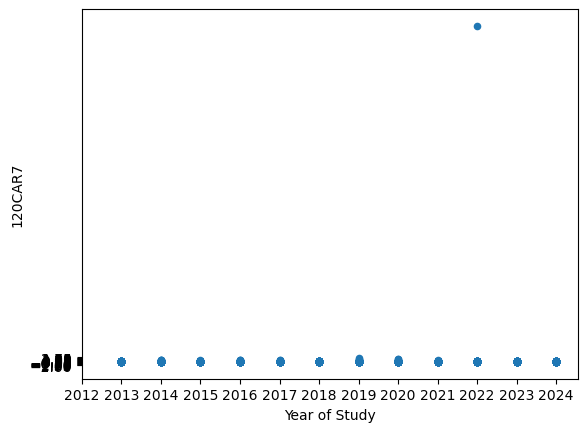

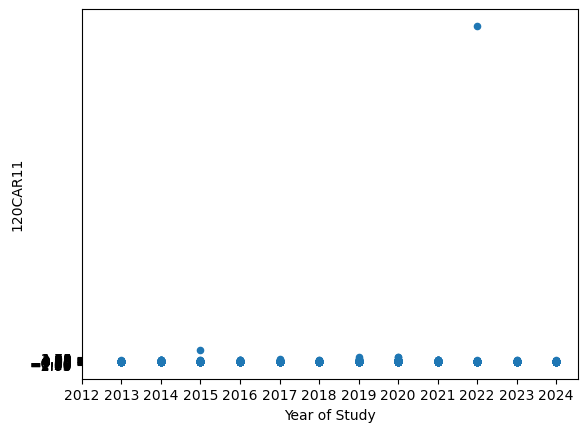

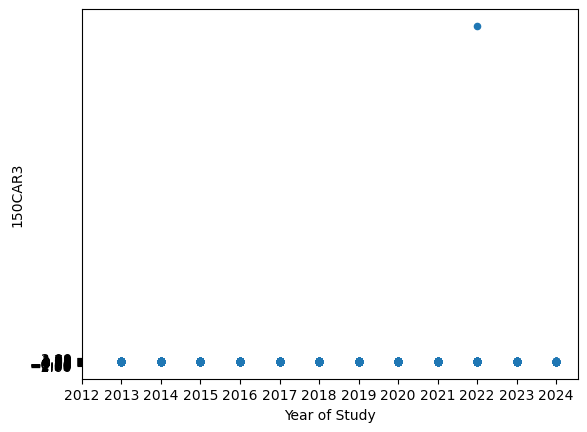

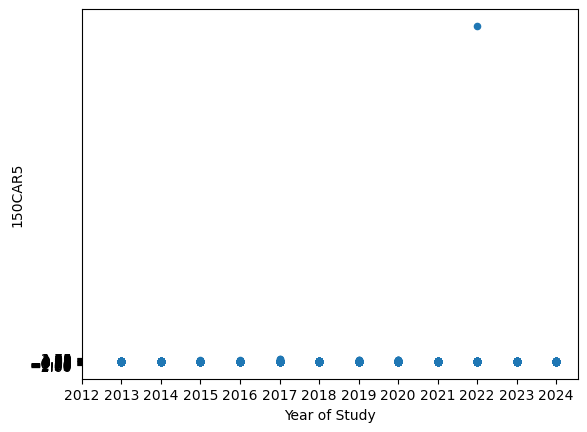

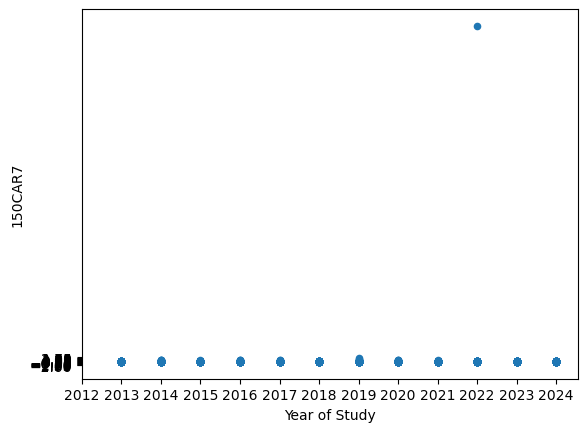

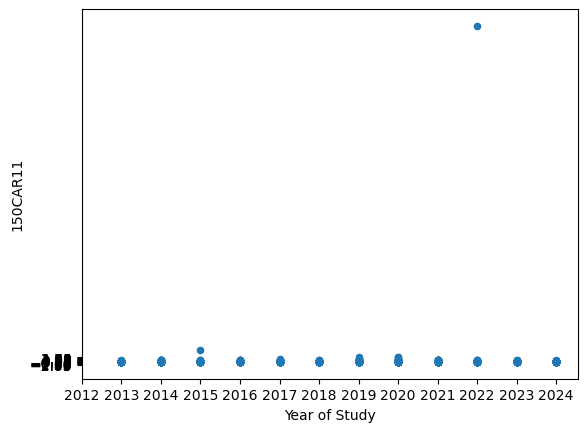

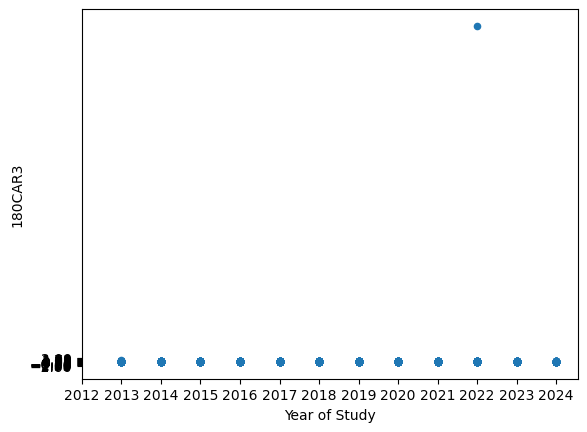

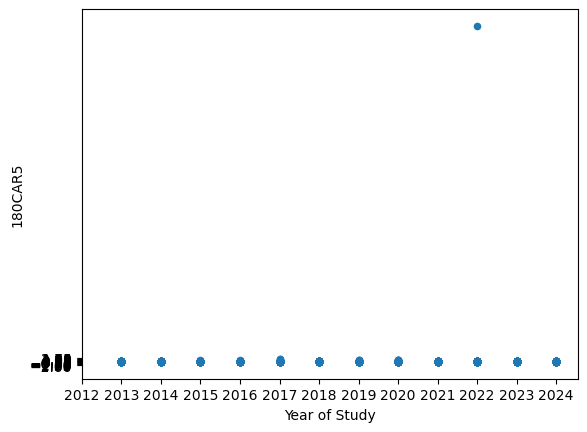

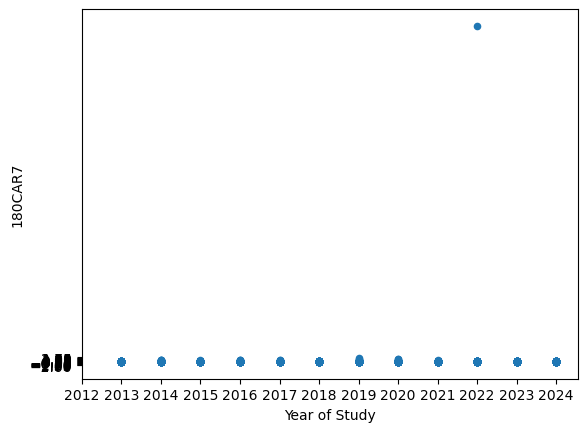

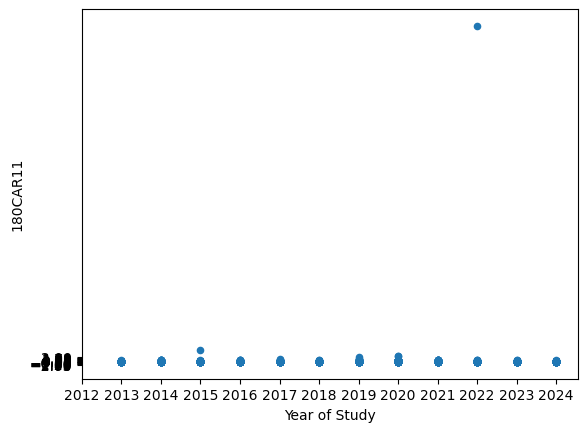

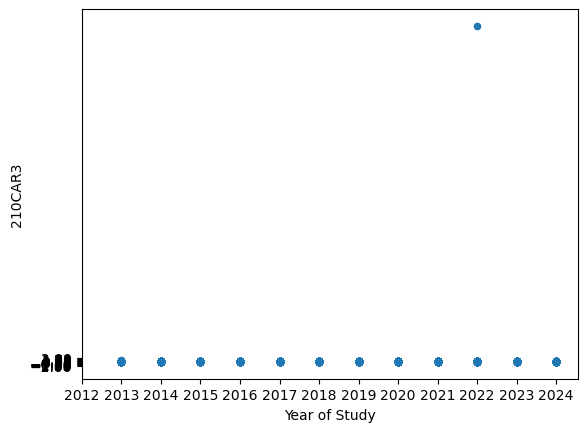

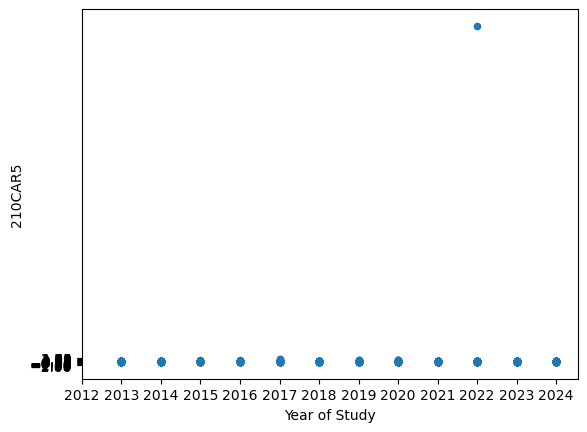

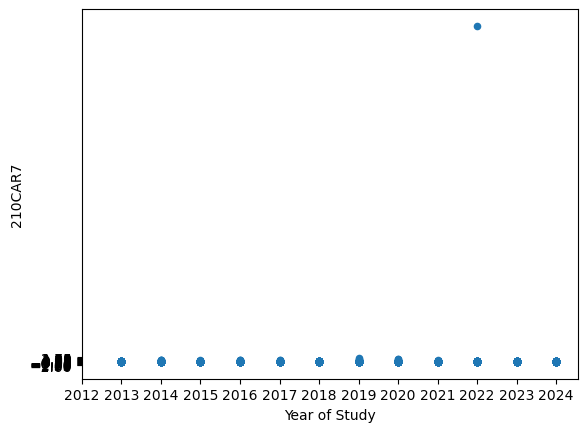

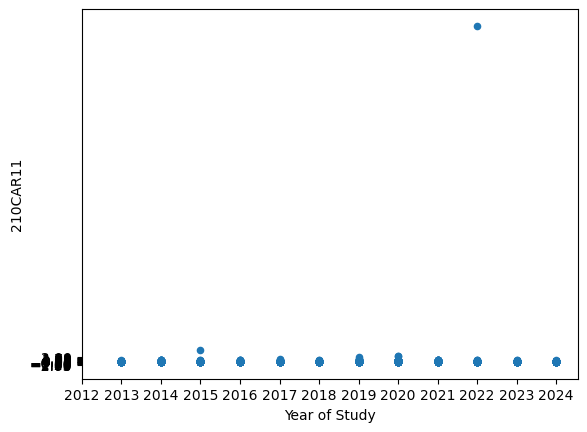

In [17]:
test = psmSampleIndep.copy()

carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

for car in carCol:
    test[car] = winsorize(test[car].values, limits = [0.01, 0.01]).data
    test[[car, "Year of Study"]].plot(kind = "scatter", x="Year of Study", y=car, xticks = np.arange(2012, 2025, step = 1), yticks = np.arange(-2, 2.25, step = 0.25))

In [18]:
test.describe()

C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the Mask

,index,AsOnDate,AsOnYear,Date of Birth,Tenure Valid till,Date of Demise,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,Ownership group code,Prowess company code,govtdummy,findummy,IsMBA,IsPhD,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,Manufacturing_NIC_not used,combined_sustainability,skill_committee_sustainability,combined_entrepreneurial,skill_committee_entrepreneurial,combined_compensation,skill_committee_compensation,combined_conglomerate_experience,skill_committee_conglomerate_experience,combined_hr,skill_committee_hr,combined_technology,skill_committee_technology,combined_finance_accounting,skill_committee_finance_accounting,combined_governance,skill_committee_governance,combined_government_policy,skill_committee_government_policy,combined_international,skill_committee_international,combined_leadership,skill_committee_leadership,combined_legal,skill_committee_legal,combined_marketing,skill_committee_marketing,combined_risk_management,skill_committee_risk_management,combined_scientific,skill_committee_scientific,combined_strategic_planning,skill_committee_strategic_planning,combined_manufacturing_supply_chain,skill_committee_manufacturing_supply_chain,skill_committee_leadership_outside_board,combined_leadership_outside_board,board_corporate governance,board_international business,board_industrials,board_utilities,board_finance,board_telecommunication,board_accounts/audit/taxation,board_public policy,board_risk management,board_research & development,board_legal/compliance,board_services,board_marketing,board_healthcare,board_strategy,board_commodities,board_operations,board_diversity,board_diversified,board_corporate social responsibility,board_human resources,board_fast moving consumer goods,board_economics,board_leadership/management,board_energy,board_financial services,board_information technology,board_personal values,board_consumer discretionary,board_supply chain management,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence,Date of Study,ProwessCode,ACP,pct,RF,RMRF,MF,SMB,HML,OLS120_intercept,OLS120_RMRF,OLS120_r_squared,OLS120_adjusted_r_squared,OLS120_f_p_value,120CAR3,120CAR5,120CAR7,120CAR11,OLS150_intercept,OLS150_RMRF,OLS150_r_squared,OLS150_adjusted_r_squared,OLS150_f_p_value,150CAR3,150CAR5,150CAR7,150CAR11

### RID

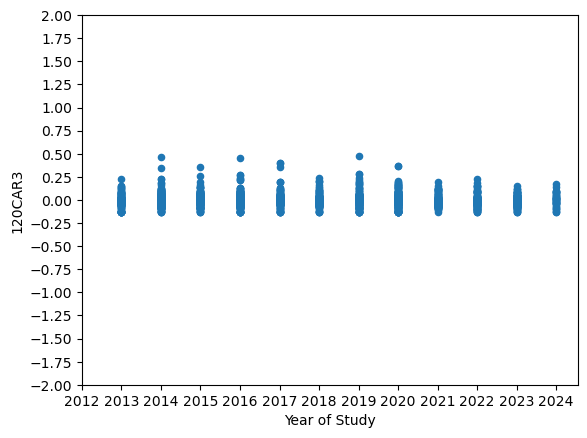

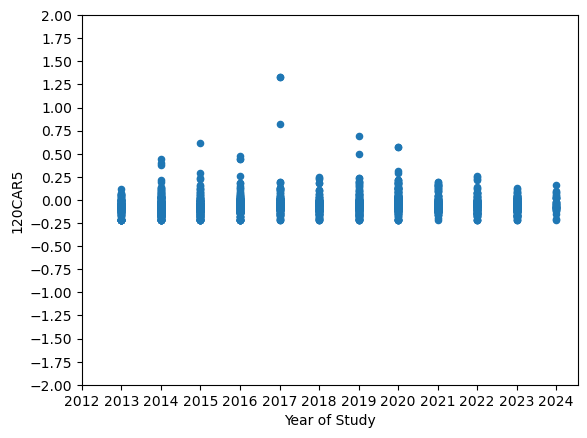

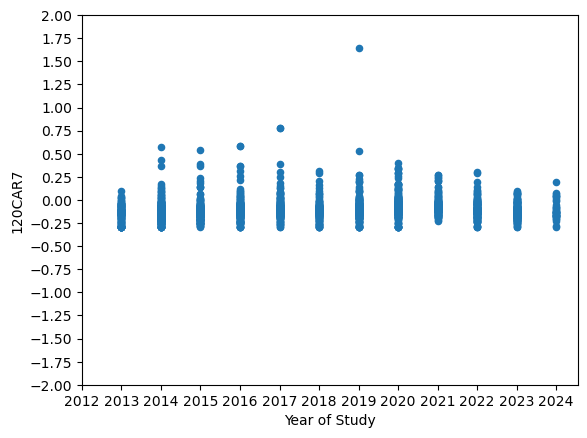

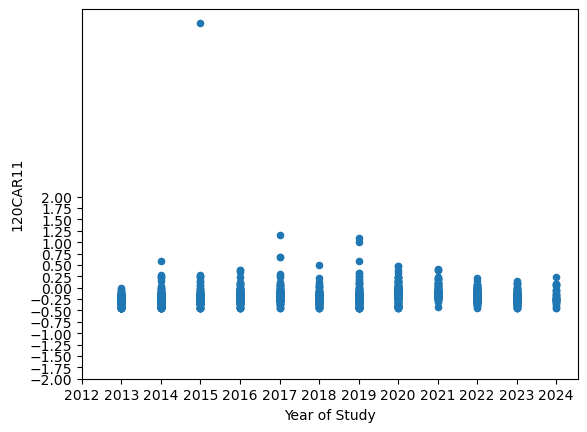

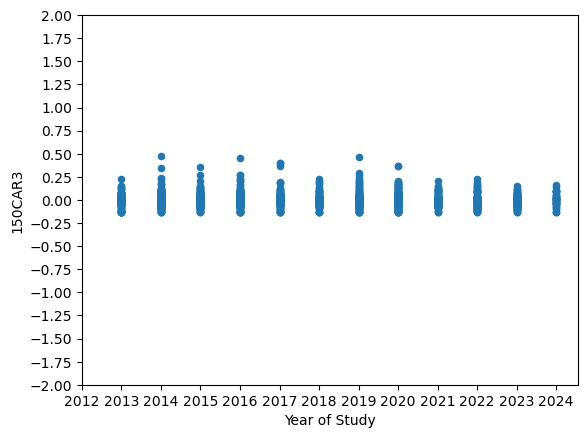

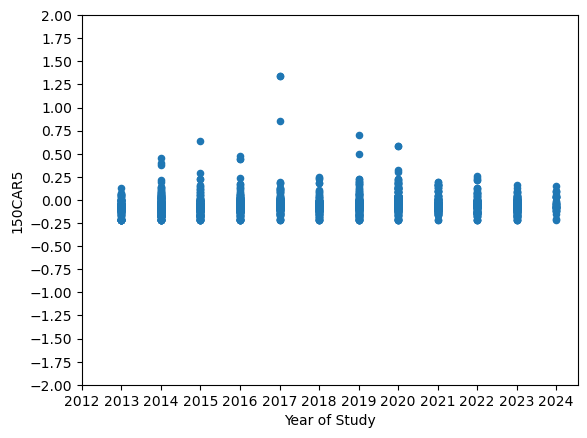

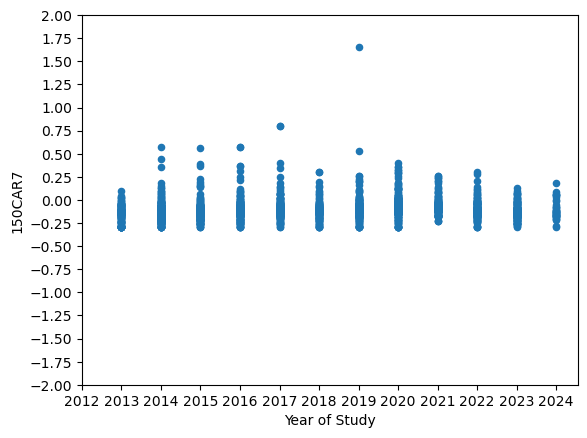

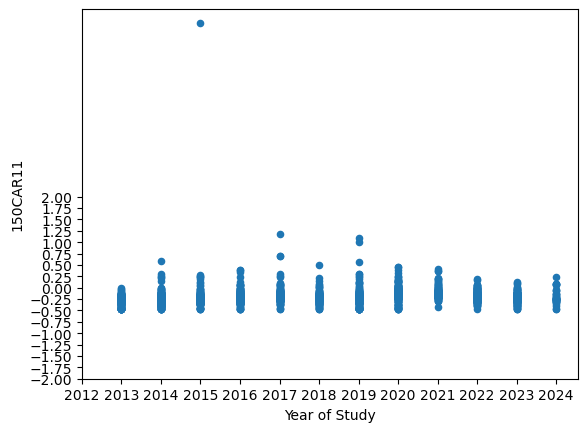

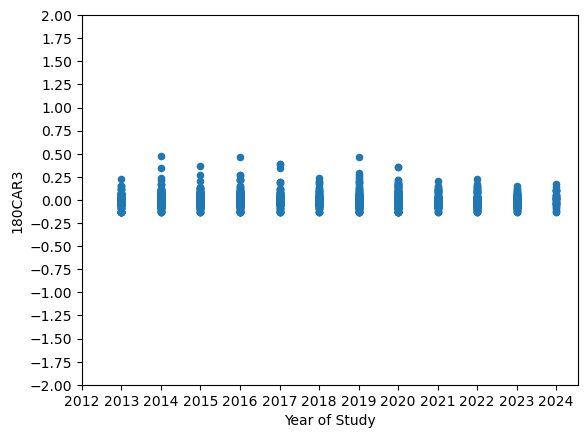

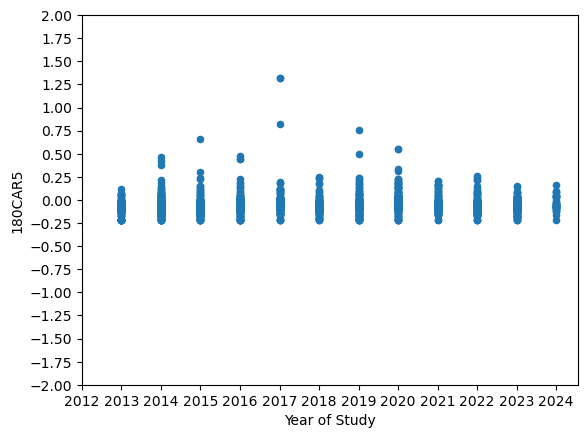

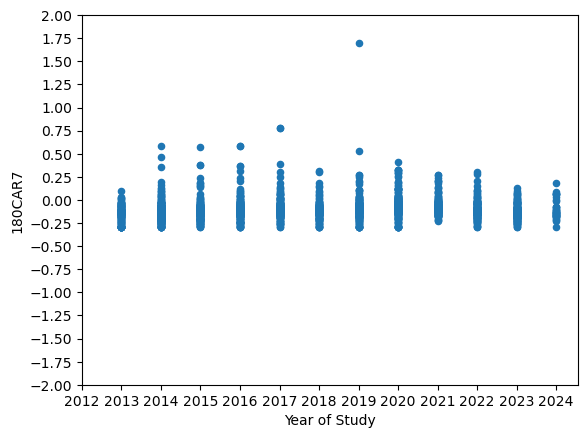

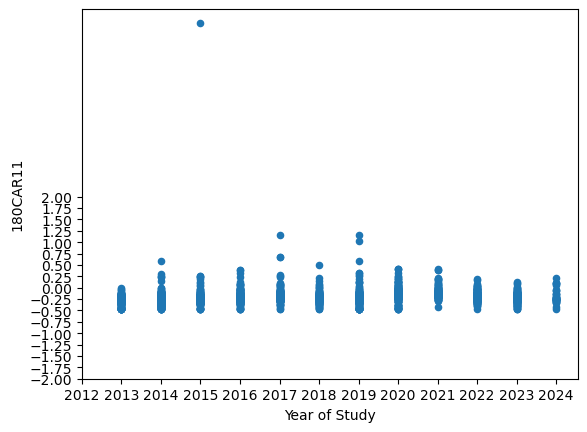

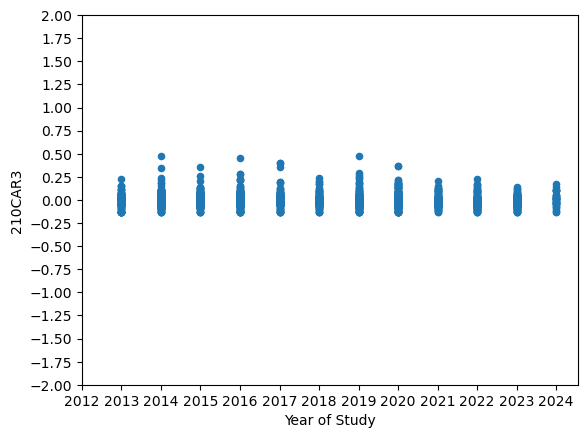

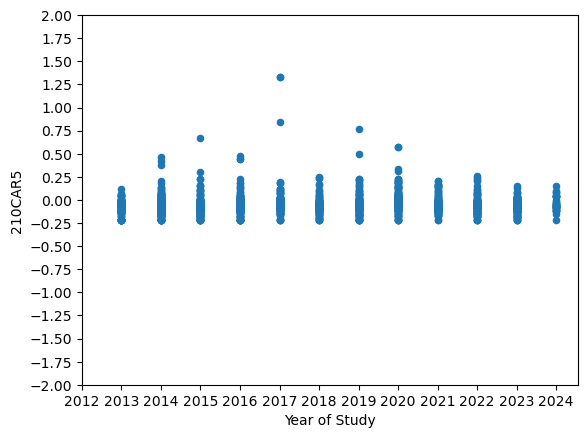

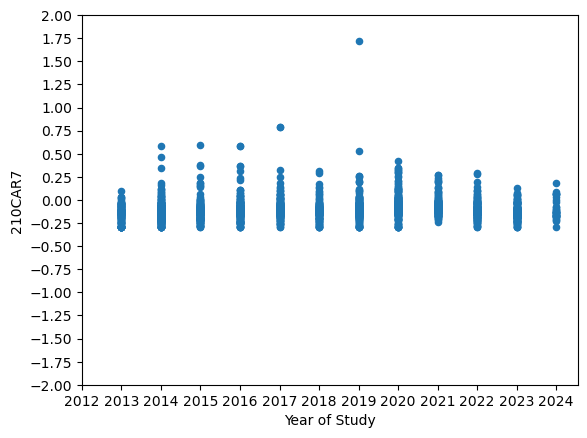

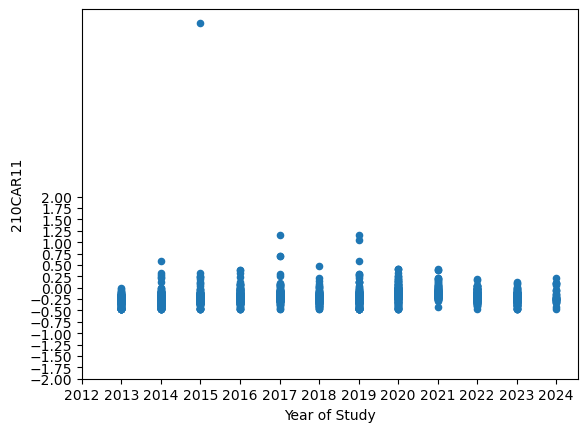

In [19]:
test = psmSampleIndep.loc[ psmSampleIndep["IsRookieIndep"] == 1 ].copy()

carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

for car in carCol:
    test[car] = winsorize(test[car].values, limits = [0.01, 0.01]).data
    test[[car, "Year of Study"]].plot(kind = "scatter", x="Year of Study", y=car, xticks = np.arange(2012, 2025, step = 1), yticks = np.arange(-2, 2.25, step = 0.25))

In [20]:
test.describe()

,index,AsOnDate,AsOnYear,Date of Birth,Tenure Valid till,Date of Demise,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,Ownership group code,Prowess company code,govtdummy,findummy,IsMBA,IsPhD,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,Manufacturing_NIC_not used,combined_sustainability,skill_committee_sustainability,combined_entrepreneurial,skill_committee_entrepreneurial,combined_compensation,skill_committee_compensation,combined_conglomerate_experience,skill_committee_conglomerate_experience,combined_hr,skill_committee_hr,combined_technology,skill_committee_technology,combined_finance_accounting,skill_committee_finance_accounting,combined_governance,skill_committee_governance,combined_government_policy,skill_committee_government_policy,combined_international,skill_committee_international,combined_leadership,skill_committee_leadership,combined_legal,skill_committee_legal,combined_marketing,skill_committee_marketing,combined_risk_management,skill_committee_risk_management,combined_scientific,skill_committee_scientific,combined_strategic_planning,skill_committee_strategic_planning,combined_manufacturing_supply_chain,skill_committee_manufacturing_supply_chain,skill_committee_leadership_outside_board,combined_leadership_outside_board,board_corporate governance,board_international business,board_industrials,board_utilities,board_finance,board_telecommunication,board_accounts/audit/taxation,board_public policy,board_risk management,board_research & development,board_legal/compliance,board_services,board_marketing,board_healthcare,board_strategy,board_commodities,board_operations,board_diversity,board_diversified,board_corporate social responsibility,board_human resources,board_fast moving consumer goods,board_economics,board_leadership/management,board_energy,board_financial services,board_information technology,board_personal values,board_consumer discretionary,board_supply chain management,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence,Date of Study,ProwessCode,ACP,pct,RF,RMRF,MF,SMB,HML,OLS120_intercept,OLS120_RMRF,OLS120_r_squared,OLS120_adjusted_r_squared,OLS120_f_p_value,120CAR3,120CAR5,120CAR7,120CAR11,OLS150_intercept,OLS150_RMRF,OLS150_r_squared,OLS150_adjusted_r_squared,OLS150_f_p_value,150CAR3,150CAR5,150CAR7,150CAR11

In [21]:
test.loc[ test["120CAR5"] >= 0.75]

,index,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,CompanyName,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_

### Non RID

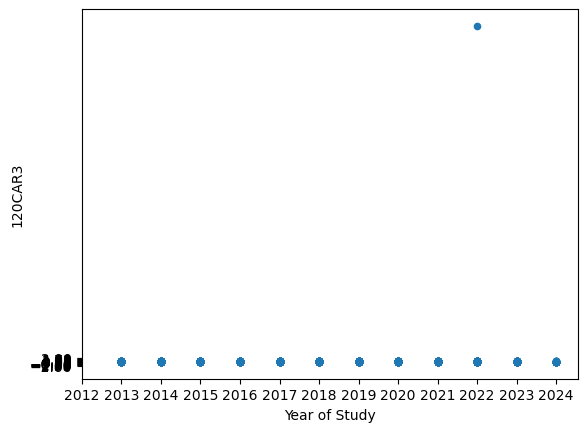

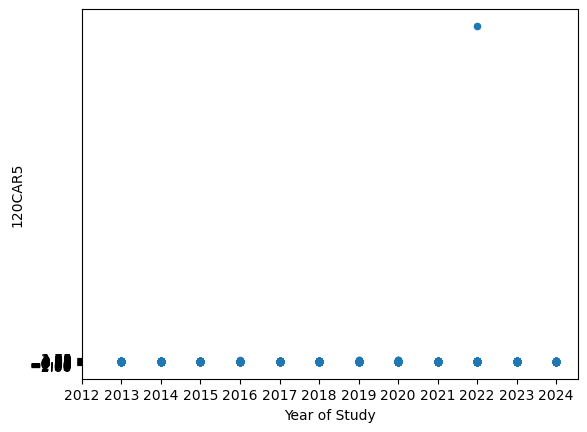

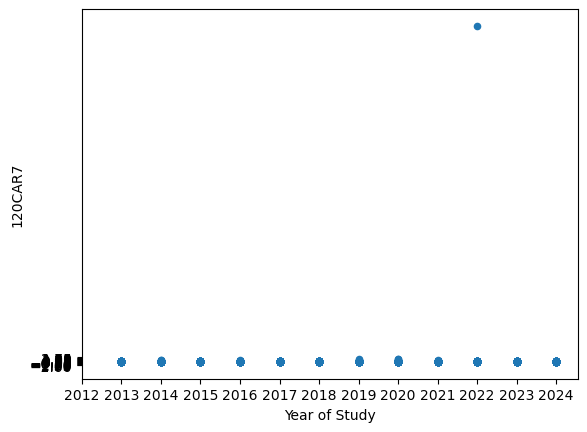

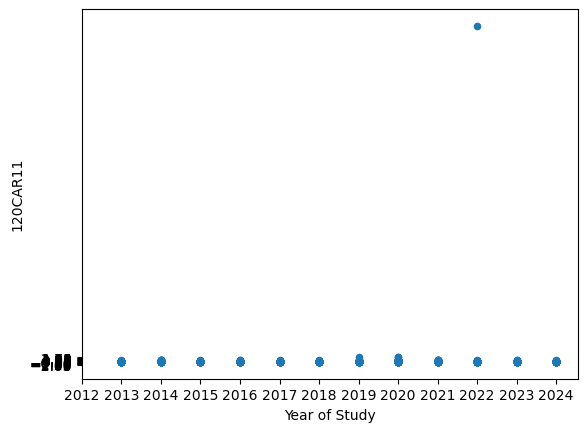

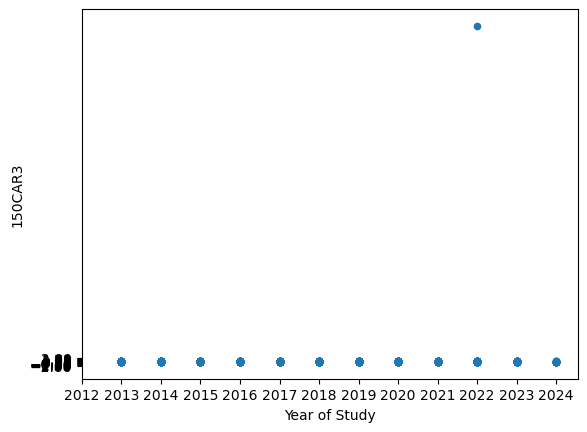

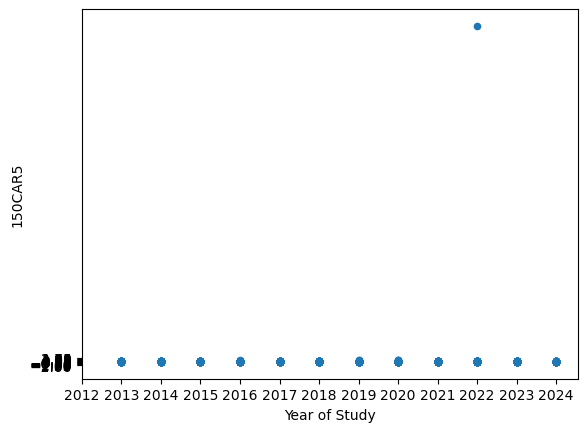

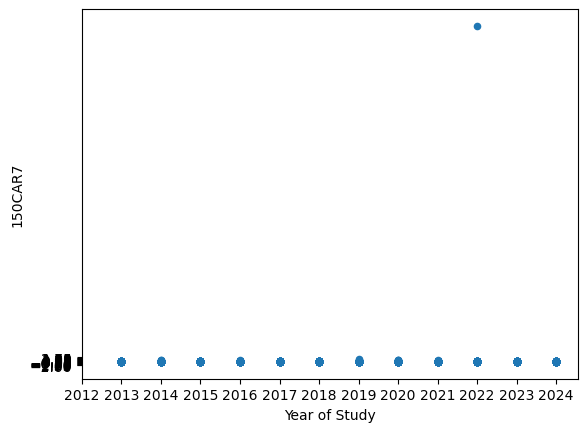

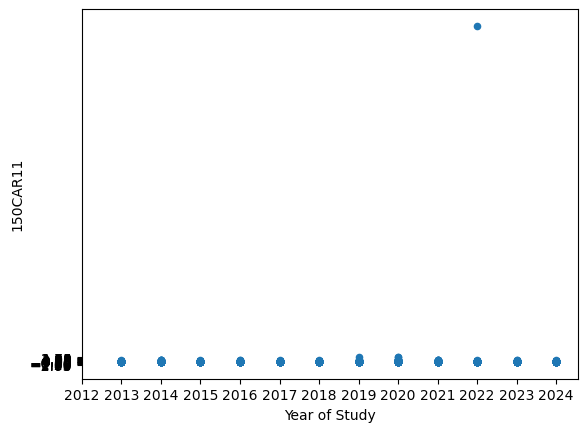

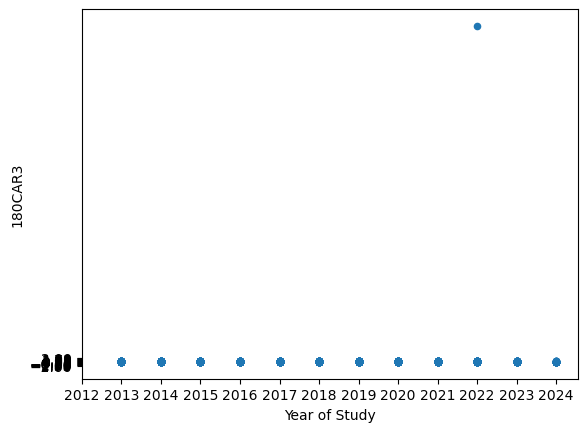

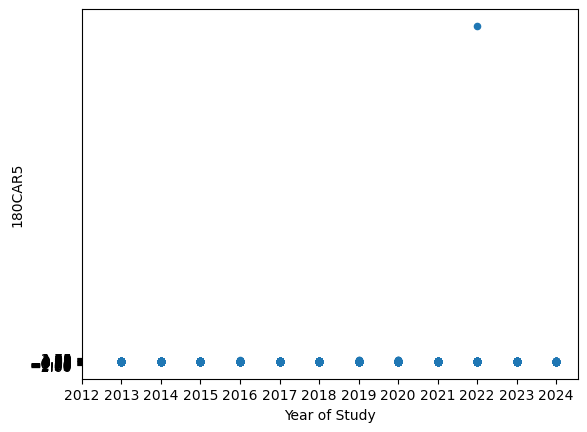

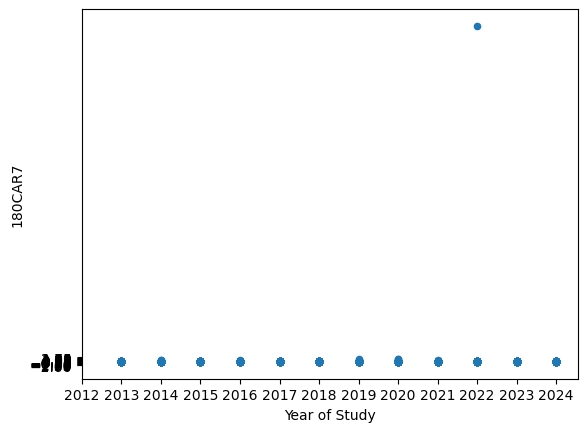

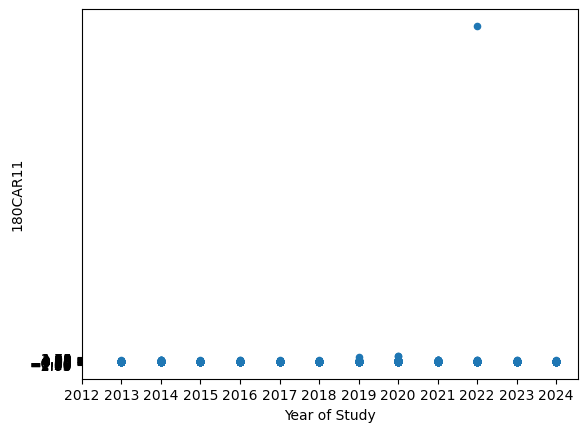

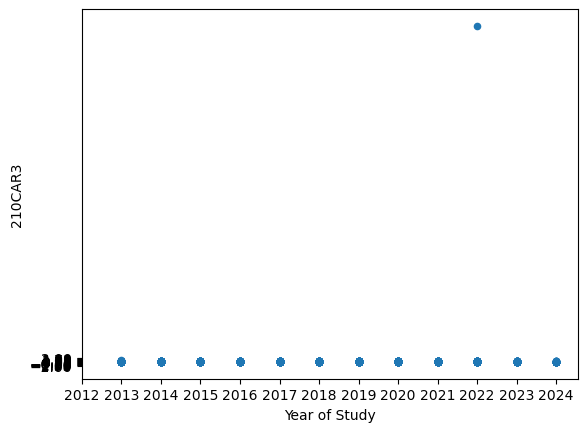

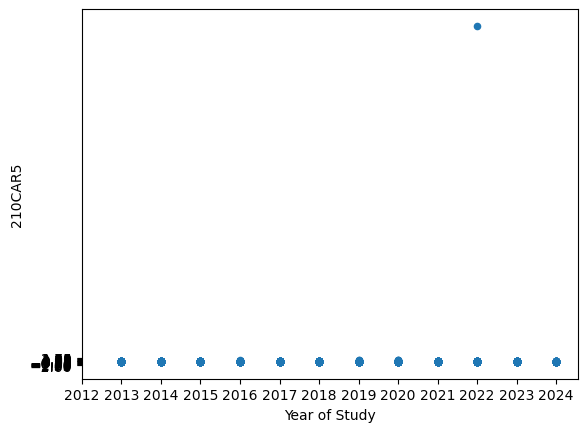

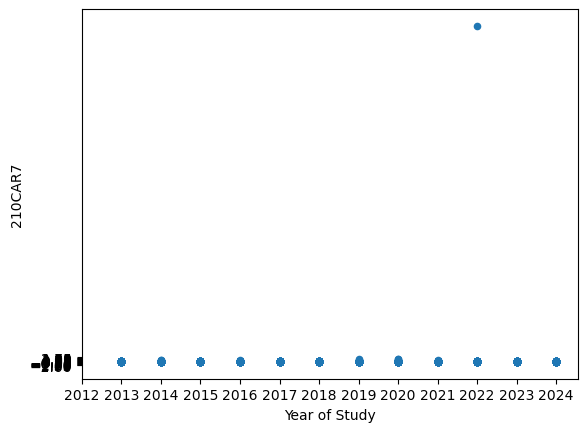

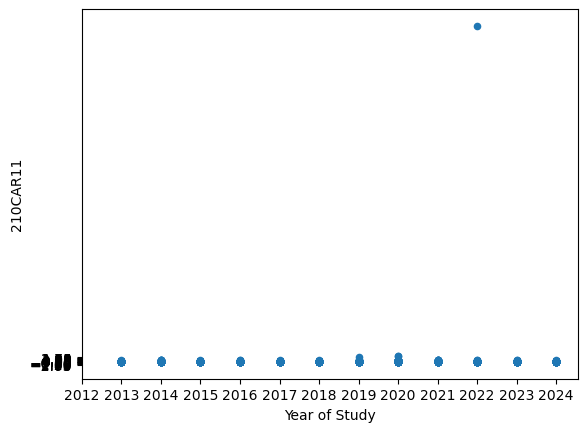

In [22]:
test = psmSampleIndep.loc[ psmSampleIndep["IsRookieIndep"] == 0 ].copy()

carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

for car in carCol:
    test[car] = winsorize(test[car].values, limits = [0.01, 0.01]).data
    test[[car, "Year of Study"]].plot(kind = "scatter", x="Year of Study", y=car, xticks = np.arange(2012, 2025, step = 1), yticks = np.arange(-2, 2.25, step = 0.25))

In [23]:
test.describe()

,index,AsOnDate,AsOnYear,Date of Birth,Tenure Valid till,Date of Demise,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,Ownership group code,Prowess company code,govtdummy,findummy,IsMBA,IsPhD,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,Manufacturing_NIC_not used,combined_sustainability,skill_committee_sustainability,combined_entrepreneurial,skill_committee_entrepreneurial,combined_compensation,skill_committee_compensation,combined_conglomerate_experience,skill_committee_conglomerate_experience,combined_hr,skill_committee_hr,combined_technology,skill_committee_technology,combined_finance_accounting,skill_committee_finance_accounting,combined_governance,skill_committee_governance,combined_government_policy,skill_committee_government_policy,combined_international,skill_committee_international,combined_leadership,skill_committee_leadership,combined_legal,skill_committee_legal,combined_marketing,skill_committee_marketing,combined_risk_management,skill_committee_risk_management,combined_scientific,skill_committee_scientific,combined_strategic_planning,skill_committee_strategic_planning,combined_manufacturing_supply_chain,skill_committee_manufacturing_supply_chain,skill_committee_leadership_outside_board,combined_leadership_outside_board,board_corporate governance,board_international business,board_industrials,board_utilities,board_finance,board_telecommunication,board_accounts/audit/taxation,board_public policy,board_risk management,board_research & development,board_legal/compliance,board_services,board_marketing,board_healthcare,board_strategy,board_commodities,board_operations,board_diversity,board_diversified,board_corporate social responsibility,board_human resources,board_fast moving consumer goods,board_economics,board_leadership/management,board_energy,board_financial services,board_information technology,board_personal values,board_consumer discretionary,board_supply chain management,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence,Date of Study,ProwessCode,ACP,pct,RF,RMRF,MF,SMB,HML,OLS120_intercept,OLS120_RMRF,OLS120_r_squared,OLS120_adjusted_r_squared,OLS120_f_p_value,120CAR3,120CAR5,120CAR7,120CAR11,OLS150_intercept,OLS150_RMRF,OLS150_r_squared,OLS150_adjusted_r_squared,OLS150_f_p_value,150CAR3,150CAR5,150CAR7,150CAR11

In [24]:
test.loc[ test["180CAR11"] >= 2]

,index,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,CompanyName,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_

## Panel A: Whole Sample

### Mean Difference

In [25]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

for car in carCol:
    sample = psmSampleIndep.dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)



120CAR3 :


T Statistic: 0.6405832235663871  P Value: 0.5218429658269134
Treated Mean: -0.00020099478203005743  Control Mean: -0.001262801731538838  Diff: 0.0010618069495087806
Treated Median: -0.005690913253664772  Control Median: -0.004860250470399039  Diff: -0.0008306627832657329
Treated N: 1920 ; Control N: 6134
[treated unique =  1920 ] [control unique =  6134 ]




120CAR5 :


T Statistic: -0.46524527645910635  P Value: 0.641789818394131
Treated Mean: -0.05161461602560344  Control Mean: -0.05060514824618891  Diff: -0.001009467779414526
Treated Median: -0.05417237942643238  Control Median: -0.05342415193722067  Diff: -0.00074822748921171
Treated N: 1920 ; Control N: 6134
[treated unique =  1920 ] [control unique =  6134 ]




120CAR7 :


T Statistic: -1.2177349828387716  P Value: 0.22342113984641662
Treated Mean: -0.10206927348066344  Control Mean: -0.09882875538151041  Diff: -0.003240518099153031
Treated Median: -0.11039996776127889  Control Median: -0.10209552805339643  Diff: 

In [26]:
### PSM without replacement
# PsmNonReplac(psmSampleIndep, "RookieIndepAppointDummy", controlVars, "ln_TobinQ_longborrowincl2", dirFirm)

### One Sample T Test

In [27]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

for car in carCol:
    sample1 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 1].copy()
    print("Rookie Independent Directors:")
    sample = sample1.dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    sample2 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 0].copy()
    print("Non Rookie Independent Directors:")
    sample = sample2.dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)


Rookie Independent Directors:


120CAR3 :


T Statistic: 0.10542978006487819  P Value: 0.9160458052780421
Mean: 0.00015872839975910152
Median: -0.005690913253664772
N: 1920


Non Rookie Independent Directors:


120CAR3 :


T Statistic: -1.7623646748315251  P Value: 0.07805750807140616
Mean: -0.0013152682656286784
Median: -0.004860250470399039
N: 6134


Rookie Independent Directors:


120CAR5 :


T Statistic: -26.03413358543227  P Value: 3.2502057974739236e-128
Mean: -0.05118790509246128
Median: -0.05417237942643238
N: 1920


Non Rookie Independent Directors:


120CAR5 :


T Statistic: -51.74530698327122  P Value: 0.0
Mean: -0.050704928439412565
Median: -0.05342415193722067
N: 6134


Rookie Independent Directors:


120CAR7 :


T Statistic: -40.72356785391904  P Value: 9.07224165242952e-262
Mean: -0.10081783216342209
Median: -0.11039996776127889
N: 1918


Non Rookie Independent Directors:


120CAR7 :


T Statistic: -83.00931632825082  P Value: 0.0
Mean: -0.09914178492298249
Median: -0.10

## Panel B: Unique skills dummy

### Mean Difference: RID vs NRID

In [28]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

for car in carCol:
    print("No unique skills:")
    sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] == 0].dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("At least one unique skill:")
    sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] != 0].dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

No unique skills:


120CAR3 :


T Statistic: 1.2957009844282321  P Value: 0.1952715286189977
Treated Mean: 0.002468431870526906  Control Mean: -0.0012823644099373736  Diff: 0.0037507962804642792
Treated Median: -0.004765008683233374  Control Median: -0.005853443125831845  Diff: 0.001088434442598471
Treated N: 832 ; Control N: 1673
[treated unique =  832 ] [control unique =  1673 ]


At least one unique skill:


120CAR3 :


T Statistic: -0.2403103623040313  P Value: 0.8101215095425907
Treated Mean: -0.001734515074867798  Control Mean: -0.001236444143054371  Diff: -0.000498070931813427
Treated Median: -0.006803435936235693  Control Median: -0.004514371218819702  Diff: -0.0022890647174159916
Treated N: 1088 ; Control N: 4461
[treated unique =  1088 ] [control unique =  4461 ]


No unique skills:


120CAR5 :


T Statistic: 0.2065061691720195  P Value: 0.8364222654714948
Treated Mean: -0.054119959546504136  Control Mean: -0.05490876872739368  Diff: 0.0007888091808895409
Treated Median: -0.0

### Mean Difference: within RID/NRID: WIP

In [29]:
# carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
#           "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
#           "180CAR3", "180CAR5", "180CAR7", "180CAR11",
#           "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

# exog_var = None
# depVar = None
# controlVars = None

# for car in carCol:
#     print("No unique skills:")
#     sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] == 0].dropna(subset = car).reset_index(drop=True).copy()
#     MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

#     print("At least one unique skill:")
#     sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] != 0].dropna(subset = car).reset_index(drop=True).copy()
#     MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

### One Sample T Test

In [30]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

for car in carCol:
    sample1 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 1].copy()
    print("Rookie Independent Directors\nNo unique skills:")
    sample = sample1.loc[sample1["NumSkills_gai"] == 0].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("At least one unique skill:")
    sample = sample1.loc[sample1["NumSkills_gai"] != 0].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    sample2 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 0].copy()
    print("Non Rookie Independent Directors\nNo unique skills:")
    sample = sample2.loc[sample2["NumSkills_gai"] == 0].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("At least one unique skill:")
    sample = sample2.loc[sample2["NumSkills_gai"] != 0].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Rookie Independent Directors
No unique skills:


120CAR3 :


T Statistic: 1.4247492485169502  P Value: 0.15460513383600033
Mean: 0.003697744503903868
Median: -0.004765008683233374
N: 832


At least one unique skill:


120CAR3 :


T Statistic: -0.8358450215842578  P Value: 0.40342578372476523
Mean: -0.001593174518146521
Median: -0.006803435936235693
N: 1088


Non Rookie Independent Directors
No unique skills:


120CAR3 :


T Statistic: -0.9303295233335159  P Value: 0.35233479548293234
Mean: -0.0014570524829242983
Median: -0.005853443125831845
N: 1673


At least one unique skill:


120CAR3 :


T Statistic: -1.4979475057420617  P Value: 0.1342176577796959
Mean: -0.0012618080431395556
Median: -0.004514371218819702
N: 4461


Rookie Independent Directors
No unique skills:


120CAR5 :


T Statistic: -14.431328305695004  P Value: 2.7149548485884066e-42
Mean: -0.051469032078014246
Median: -0.055867333540763564
N: 832


At least one unique skill:


120CAR5 :


T Statistic: -19.722557363948447  P

In [31]:
### PSM without replacement
# PsmNonReplac(psmSampleIndep, "RookieIndepAppointDummy", controlVars, "ln_TobinQ_longborrowincl2", dirFirm)

## Panel C: Number of Skills

### Mean Difference

In [32]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

num_skills_median = psmSampleIndep.drop_duplicates(subset = ["AsOnDate", "Person Code"])["NumSkills_gai"].median()
for car in carCol:
    print("Less than median no. skills:")
    sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] < num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("Greater than median no. skills:")
    sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] > num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Less than median no. skills:


120CAR3 :


T Statistic: 0.498193012435669  P Value: 0.6183914180841665
Treated Mean: -0.00040677664098321054  Control Mean: -0.0014470839958966254  Diff: 0.001040307354913415
Treated Median: -0.005797917116895458  Control Median: -0.005289952952377552  Diff: -0.0005079641645179059
Treated N: 1424 ; Control N: 3251
[treated unique =  1424 ] [control unique =  3251 ]


Greater than median no. skills:


120CAR3 :


T Statistic: 1.0433260891418328  P Value: 0.29724666481610995
Treated Mean: 0.002052098829571192  Control Mean: -0.001099474374878071  Diff: 0.0031515732044492635
Treated Median: -0.002550605597299929  Control Median: -0.0044504847822634756  Diff: 0.0018998791849635464
Treated N: 437 ; Control N: 2734
[treated unique =  437 ] [control unique =  2734 ]


Less than median no. skills:


120CAR5 :


T Statistic: -0.3699479657109636  P Value: 0.7114518850104479
Treated Mean: -0.05481888573831859  Control Mean: -0.05381310898068498  Diff: -0.0010057767

### One Sample T Test

In [33]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

num_skills_median = psmSampleIndep.drop_duplicates(subset = ["AsOnDate", "Person Code"])["NumSkills_gai"].median()
for car in carCol:
    sample1 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 1].copy()
    print("Rookie Independent Directors\nLess than median no. skills:")
    sample = sample1.loc[sample1["NumSkills_gai"] < num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("Greater than median no. skills:")
    sample = sample1.loc[sample1["NumSkills_gai"] < num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    sample2 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 0].copy()
    print("Non Rookie Independent Directors\nLess than median no. skills:")
    sample = sample2.loc[sample2["NumSkills_gai"] > num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("Greater than median no. skills:")
    sample = sample2.loc[sample2["NumSkills_gai"] > num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Rookie Independent Directors
Less than median no. skills:


120CAR3 :


T Statistic: -0.045414379528070634  P Value: 0.963783391629156
Mean: -8.230113121283209e-05
Median: -0.005797917116895458
N: 1424


Greater than median no. skills:


120CAR3 :


T Statistic: -0.045414379528070634  P Value: 0.963783391629156
Mean: -8.230113121283209e-05
Median: -0.005797917116895458
N: 1424


Non Rookie Independent Directors
Less than median no. skills:


120CAR3 :


T Statistic: -1.127259414671039  P Value: 0.2597317748214563
Mean: -0.0011730383427924693
Median: -0.0044504847822634756
N: 2734


Greater than median no. skills:


120CAR3 :


T Statistic: -1.127259414671039  P Value: 0.2597317748214563
Mean: -0.0011730383427924693
Median: -0.0044504847822634756
N: 2734


Rookie Independent Directors
Less than median no. skills:


120CAR5 :


T Statistic: -22.801604640132446  P Value: 2.4065209597023762e-98
Mean: -0.054151882977314596
Median: -0.055557326058193836
N: 1424


Greater than median no. skil

In [34]:
### PSM without replacement
# PsmNonReplac(psmSampleIndep, "RookieIndepAppointDummy", controlVars, "ln_TobinQ_longborrowincl2", dirFirm)